In [1]:
!pip install scipy numpy matplotlib scikit-learn rasterio




In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import scipy.io
import rasterio
import numpy as np

# Load the .mat file
mat_file = "/content/drive/MyDrive/model/pavia_cnn.mat"  # Update with your actual path
data = scipy.io.loadmat(mat_file)

# Check available keys
print("Keys in .mat file:", data.keys())

# Extract HR_MSI data
if "HR_MSI" in data:
    hr_msi_data = data["HR_MSI"]
    print(f"✅ HR_MSI Shape: {hr_msi_data.shape}")  # Expected: (Height, Width, Bands)
else:
    raise KeyError("❌ 'HR_MSI' key not found in the .mat file!")


Keys in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'HR_MSI', 'LR_HSI', 'HR_HSI', 'LR_MSI'])
✅ HR_MSI Shape: (200, 200, 4)


In [ ]:
import scipy.io
import numpy as np
import rasterio
from rasterio.transform import from_origin

# Load the .mat file
mat_data = scipy.io.loadmat('/content/drive/MyDrive/hyperiondata/PaviaU.mat')

# Extract hyperspectral image data
hyperspectral_data = mat_data['paviaU']  # Shape: (610, 340, 103)

# Convert data type (optional: normalize if needed)
hyperspectral_data = hyperspectral_data.astype(np.float32)

# Define geotransform (assuming top-left at (0,0) and 1.3m resolution)
transform = from_origin(0, 0, 1.3, 1.3)

# Save as GeoTIFF
output_tif_path = "/content/drive/MyDrive/model/PaviaU.tif"

with rasterio.open(
    output_tif_path,
    'w',
    driver='GTiff',
    height=hyperspectral_data.shape[0],
    width=hyperspectral_data.shape[1],
    count=hyperspectral_data.shape[2],  # Number of bands (103)
    dtype=rasterio.float32,
    crs='EPSG:32632',  # UTM Zone 32N (for Northern Italy)
    transform=transform
) as dst:
    for i in range(hyperspectral_data.shape[2]):
        dst.write(hyperspectral_data[:, :, i], i + 1)

print(f"GeoTIFF saved at: {output_tif_path}")


GeoTIFF saved at: /content/drive/MyDrive/model/PaviaU.tif


In [ ]:
import rasterio
import numpy as np
import scipy.io

# Load the .mat file
mat_file = "/content/drive/MyDrive/model/pavia_cnn.mat"  # Update with your actual path
data = scipy.io.loadmat(mat_file)

# Extract HR_MSI data
hr_msi_data = data["HR_MSI"]  # Shape: (200, 200, 4)
print(f"✅ HR_MSI Shape: {hr_msi_data.shape}")

# Define output TIFF file path
hr_msi_tiff_path = "/content/drive/MyDrive/model/HR_MSI_Image.tif"

# Function to save as TIFF
def save_as_tiff(image_data, output_path):
    height, width, bands = image_data.shape
    with rasterio.open(
        output_path, "w", driver="GTiff", height=height, width=width,
        count=bands, dtype=image_data.dtype
    ) as dst:
        for i in range(bands):
            dst.write(image_data[:, :, i], i + 1)
    print(f"✅ Saved TIFF: {output_path}")

# Save HR_MSI as a TIFF file
save_as_tiff(hr_msi_data, hr_msi_tiff_path)


✅ HR_MSI Shape: (200, 200, 4)
✅ Saved TIFF: /content/drive/MyDrive/model/HR_MSI_Image.tif


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


In [ ]:
import scipy.io

# Load the .mat file
dataset_path = "/content/drive/MyDrive/model/ALI_Hyperion22_data.mat"
mat_data = scipy.io.loadmat(dataset_path)

# List all available keys in the file
print("Keys in .mat file:", mat_data.keys())

# Extract ALI and Hyperion if they exist
ALI = mat_data.get("ALI", None)
Hyperion = mat_data.get("Hyperion", None)

# Check data availability
if ALI is not None:
    print(f"✅ ALI Shape: {ALI_data.shape}")  # Expected: (H, W, 9)
else:
    print("❌ ALI data not found in .mat file!")

if Hyperion is not None:
    print(f"✅ Hyperion Shape: {Hyperion_data.shape}")  # Expected: (H, W, 155)
else:
    print("❌ Hyperion data not found in .mat file!")


Keys in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'ALI_data', 'ALI_metadata', 'Hyperion_data', 'Hyperion_metadata'])
❌ ALI data not found in .mat file!
❌ Hyperion data not found in .mat file!


In [ ]:
import scipy.io
import numpy as np

# Load .mat file
mat_data = scipy.io.loadmat('/content/drive/MyDrive/model/ALI_Hyperion22_data.mat')

# Extract data
ALI = mat_data['ALI']
Hyperion = mat_data['Hyperion']

# Get target shape (Hyperion)
target_shape = Hyperion.shape[:2]  # (202, 126)

# Find the center of the ALI image
center_x = ALI.shape[1] // 2
center_y = ALI.shape[0] // 2

# Compute cropping box
start_x = center_x - (target_shape[1] // 2)
start_y = center_y - (target_shape[0] // 2)

# Crop ALI to match Hyperion
ALI_cropped = ALI[start_y:start_y + target_shape[0], start_x:start_x + target_shape[1], :]

print("✅ Cropped ALI Shape:", ALI_cropped.shape)  # Should be (202, 126, 9)


KeyError: 'ALI'

In [4]:
!pip install tensorflow scipy numpy pandas matplotlib rasterio tensorflow-addons



ERROR: Could not find a version that satisfies the requirement tensorflow-addons (from versions: none)
ERROR: No matching distribution found for tensorflow-addons


In [ ]:
!pip install rasterio

import tensorflow as tf
import numpy as np
import scipy.io
import os
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------------------------- Parameter Settings --------------------------------------------------
patch_size = 4            # Input patch size
epoch = 50                # Number of training epochs
batch_size = 32           # Standard batch size
learning_rate_base = 0.01 # Initial learning rate

# -------------------------------------------------- Load Data --------------------------------------------------
print('Loading Data and Generating Training/Testing Samples...')

DATA_PATH = "/content/drive/MyDrive/model"

# Load Pavia University Hyperspectral Dataset
mat_data = scipy.io.loadmat(os.path.join(DATA_PATH, 'pavia_cnn.mat'))
HR_MSI = mat_data['HR_MSI']
HR_HSI = mat_data['HR_HSI']

# Get image dimensions
Height_HR, Width_HR, Band_MSI = HR_MSI.shape
Band_HSI = HR_HSI.shape[2]

print(f"The Shape of HR-MSI: {HR_MSI.shape}")
print(f"The Shape of HR-HSI: {HR_HSI.shape}")

# Normalize Data
HR_MSI = HR_MSI.astype(np.float32) / np.max(HR_MSI)
HR_HSI = HR_HSI.astype(np.float32) / np.max(HR_HSI)

# -------------------------------------------------- Split Data into Training & Testing --------------------------------------------------
split_index = int(Width_HR * 0.7)  # 70% training, 30% testing
Training_MSI = HR_MSI[:, :split_index, :]
Training_HSI = HR_HSI[:, :split_index, :]
Testing_MSI = HR_MSI[:, split_index:, :]
Testing_HSI = HR_HSI[:, split_index:, :]

print(f"Training Data Shape: {Training_MSI.shape}, {Training_HSI.shape}")
print(f"Testing Data Shape: {Testing_MSI.shape}, {Testing_HSI.shape}")

# ✅ **Fix 1: Extract Training Patches Properly**
def extract_patches(data, patch_size):
    """ Extracts patches from hyperspectral images (batch, patch_size, patch_size, channels) """
    patches = []
    for i in range(0, data.shape[0] - patch_size + 1, patch_size):
        for j in range(0, data.shape[1] - patch_size + 1, patch_size):
            patch = data[i:i + patch_size, j:j + patch_size, :]
            patches.append(patch)
    return np.array(patches)

Train_MSI_Patches = extract_patches(Training_MSI, patch_size)
Train_HSI_Patches = extract_patches(Training_HSI, patch_size)
Test_MSI_Patches = extract_patches(Testing_MSI, patch_size)
Test_HSI_Patches = extract_patches(Testing_HSI, patch_size)

print(f"✅ Train MSI Shape: {Train_MSI_Patches.shape}, Train HSI Shape: {Train_HSI_Patches.shape}")
print(f"✅ Test MSI Shape: {Test_MSI_Patches.shape}, Test HSI Shape: {Test_HSI_Patches.shape}")

# -------------------------------------------------- Define Efficient Channel Attention (ECA) --------------------------------------------------
class ECALayer(tf.keras.layers.Layer):
    """ Efficient Channel Attention (ECA) as a Keras Layer """
    def __init__(self, k_size=5, **kwargs):
        super(ECALayer, self).__init__(**kwargs)
        self.k_size = k_size
        self.global_avg_pool = tf.keras.layers.GlobalAveragePooling2D(keepdims=True)
        self.conv1d = tf.keras.layers.Conv1D(filters=1, kernel_size=k_size, padding="same", activation="sigmoid", use_bias=False)

    def call(self, inputs):
        gap = self.global_avg_pool(inputs)  # Shape: (batch, 1, 1, channels)
        gap_reshaped = tf.keras.layers.Reshape((-1, 1))(gap)  # Shape: (batch, channels, 1)
        attention = self.conv1d(gap_reshaped)  # Apply Conv1D attention
        attention = tf.keras.layers.Reshape((1, 1, -1))(attention)  # Reshape back to (batch, 1, 1, channels)
        return inputs * attention  # Apply attention scaling

# -------------------------------------------------- Define the CNN Model with 3 Residual Blocks --------------------------------------------------
def build_model(input_shape, output_channels):
    inputs = tf.keras.Input(shape=input_shape)

    # 🔹 Initial 1x1 Convolution to match channels
    x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(inputs)

    # ✅ **Fix 2: Ensure skip connections match feature dimensions**
    shortcut = x

    # 🔹 Residual Block 1
    x1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x2 = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = tf.keras.layers.Concatenate()([x1, x2])
    x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = ECALayer(k_size=5)(x)
    x = tf.keras.layers.Add()([x, shortcut])  # Skip Connection

    # 🔹 Residual Block 2
    shortcut = x  # Update shortcut to the latest x
    x1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x2 = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = tf.keras.layers.Concatenate()([x1, x2])
    x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = ECALayer(k_size=5)(x)
    x = tf.keras.layers.Add()([x, shortcut])  # Skip Connection

    # 🔹 Residual Block 3
    shortcut = x  # Update shortcut again
    x1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x2 = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = tf.keras.layers.Concatenate()([x1, x2])
    x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = ECALayer(k_size=5)(x)
    x = tf.keras.layers.Add()([x, shortcut])  # Skip Connection

    # 🔹 Output Layer
    outputs = tf.keras.layers.Conv2D(output_channels, (1, 1), activation=None, padding='same')(x)
    outputs = ECALayer(k_size=5)(outputs)

    model = tf.keras.Model(inputs, outputs)
    return model

# -------------------------------------------------- Train the Model --------------------------------------------------
input_shape = (patch_size, patch_size, Band_MSI)
output_channels = Band_HSI

model = build_model(input_shape, output_channels)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate_base), loss='mse')

# ✅ **Fix 3: Pass Correctly Reshaped Training Data**
model.fit(Train_MSI_Patches, Train_HSI_Patches, batch_size=batch_size, epochs=epoch, validation_data=(Test_MSI_Patches, Test_HSI_Patches))

# Save Model
model.save("/content/trained_hyperspectral_model.h5")

print("✅ Model Training Complete & Saved!")



In [ ]:
import tensorflow as tf
import numpy as np
import scipy.io
import os
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------------------------- Parameter Settings --------------------------------------------------
patch_size = 4            # Input patch size
epoch = 50                # Number of training epochs
batch_size = 32           # Standard batch size
learning_rate_base = 0.01 # Initial learning rate

# -------------------------------------------------- Load Data --------------------------------------------------
print('Loading Data and Generating Training/Testing Samples...')

DATA_PATH = "/content/drive/MyDrive/model"

# Load Pavia University Hyperspectral Dataset
mat_data = scipy.io.loadmat(os.path.join(DATA_PATH, 'pavia_cnn.mat'))
HR_MSI = mat_data['HR_MSI']
HR_HSI = mat_data['HR_HSI']

# Get image dimensions
Height_HR, Width_HR, Band_MSI = HR_MSI.shape
Band_HSI = HR_HSI.shape[2]

print(f"The Shape of HR-MSI: {HR_MSI.shape}")
print(f"The Shape of HR-HSI: {HR_HSI.shape}")

# Normalize Data
HR_MSI = HR_MSI.astype(np.float32) / np.max(HR_MSI)
HR_HSI = HR_HSI.astype(np.float32) / np.max(HR_HSI)

# -------------------------------------------------- Split Data into Training & Testing --------------------------------------------------
split_index = int(Width_HR * 0.7)  # 70% training, 30% testing
Training_MSI = HR_MSI[:, :split_index, :]
Training_HSI = HR_HSI[:, :split_index, :]
Testing_MSI = HR_MSI[:, split_index:, :]
Testing_HSI = HR_HSI[:, split_index:, :]

print(f"Training Data Shape: {Training_MSI.shape}, {Training_HSI.shape}")
print(f"Testing Data Shape: {Testing_MSI.shape}, {Testing_HSI.shape}")

# ✅ **Fix 1: Extract Training Patches Properly**
def extract_patches(data, patch_size):
    """ Extracts patches from hyperspectral images (batch, patch_size, patch_size, channels) """
    patches = []
    for i in range(0, data.shape[0] - patch_size + 1, patch_size):
        for j in range(0, data.shape[1] - patch_size + 1, patch_size):
            patch = data[i:i + patch_size, j:j + patch_size, :]
            patches.append(patch)
    return np.array(patches)

Train_MSI_Patches = extract_patches(Training_MSI, patch_size)
Train_HSI_Patches = extract_patches(Training_HSI, patch_size)
Test_MSI_Patches = extract_patches(Testing_MSI, patch_size)
Test_HSI_Patches = extract_patches(Testing_HSI, patch_size)

print(f"✅ Train MSI Shape: {Train_MSI_Patches.shape}, Train HSI Shape: {Train_HSI_Patches.shape}")
print(f"✅ Test MSI Shape: {Test_MSI_Patches.shape}, Test HSI Shape: {Test_HSI_Patches.shape}")

# -------------------------------------------------- Define Efficient Channel Attention (ECA) --------------------------------------------------
class ECALayer(tf.keras.layers.Layer):
    """ Efficient Channel Attention (ECA) as a Keras Layer """
    def __init__(self, k_size=5, **kwargs):
        super(ECALayer, self).__init__(**kwargs)
        self.k_size = k_size
        self.global_avg_pool = tf.keras.layers.GlobalAveragePooling2D(keepdims=True)
        self.conv1d = tf.keras.layers.Conv1D(filters=1, kernel_size=k_size, padding="same", activation="sigmoid", use_bias=False)

    def call(self, inputs):
        gap = self.global_avg_pool(inputs)  # Shape: (batch, 1, 1, channels)
        gap_reshaped = tf.keras.layers.Reshape((-1, 1))(gap)  # Shape: (batch, channels, 1)
        attention = self.conv1d(gap_reshaped)  # Apply Conv1D attention
        attention = tf.keras.layers.Reshape((1, 1, -1))(attention)  # Reshape back to (batch, 1, 1, channels)
        return inputs * attention  # Apply attention scaling

# -------------------------------------------------- Define the CNN Model with 3 Residual Blocks --------------------------------------------------
def build_model(input_shape, output_channels):
    inputs = tf.keras.Input(shape=input_shape)

    # 🔹 Initial 1x1 Convolution to match channels
    x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(inputs)

    # ✅ **Fix 2: Ensure skip connections match feature dimensions**
    shortcut = x

    # 🔹 Residual Block 1
    x1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x2 = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = tf.keras.layers.Concatenate()([x1, x2])
    x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = ECALayer(k_size=5)(x)
    x = tf.keras.layers.Add()([x, shortcut])  # Skip Connection

    # 🔹 Residual Block 2
    shortcut = x  # Update shortcut to the latest x
    x1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x2 = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = tf.keras.layers.Concatenate()([x1, x2])
    x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = ECALayer(k_size=5)(x)
    x = tf.keras.layers.Add()([x, shortcut])  # Skip Connection

    # 🔹 Residual Block 3
    shortcut = x  # Update shortcut again
    x1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x2 = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = tf.keras.layers.Concatenate()([x1, x2])
    x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = ECALayer(k_size=5)(x)
    x = tf.keras.layers.Add()([x, shortcut])  # Skip Connection

    # 🔹 Output Layer
    outputs = tf.keras.layers.Conv2D(output_channels, (1, 1), activation=None, padding='same')(x)
    outputs = ECALayer(k_size=5)(outputs)

    model = tf.keras.Model(inputs, outputs)
    return model

# -------------------------------------------------- Train the Model --------------------------------------------------
input_shape = (patch_size, patch_size, Band_MSI)
output_channels = Band_HSI

model = build_model(input_shape, output_channels)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate_base), loss='mse')

# ✅ **Fix 3: Pass Correctly Reshaped Training Data**
model.fit(Train_MSI_Patches, Train_HSI_Patches, batch_size=batch_size, epochs=epoch, validation_data=(Test_MSI_Patches, Test_HSI_Patches))

# Save Model
model.save("/content/drive/MyDrive/model/trained_hyperspectral_model.h5")

print("✅ Model Training Complete & Saved!")

# --------------------------------------------------
# ✅ Evaluate Model Accuracy
from sklearn.metrics import mean_squared_error
from math import log10
import numpy as np

# Predict on Test MSI Patches
predicted_HSI = model.predict(Test_MSI_Patches)

# Flatten for comparison
y_true = Test_HSI_Patches.reshape(-1, Band_HSI)
y_pred = predicted_HSI.reshape(-1, Band_HSI)

# RMSE
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
print(f"🔹 RMSE (Root Mean Squared Error): {rmse:.4f}")

# PSNR
mse = np.mean((y_true - y_pred) ** 2)
if mse == 0:
    psnr = float('inf')
else:
    psnr = 20 * log10(1.0 / np.sqrt(mse))  # Assumes normalized data in [0,1]
print(f"🔹 PSNR (Peak Signal-to-Noise Ratio): {psnr:.2f} dB")

# Optional: Percentage Accuracy (as 1 - Normalized RMSE)
normalized_rmse = rmse / (np.max(y_true) - np.min(y_true))
accuracy = (1 - normalized_rmse) * 100
print(f"✅ Overall Approximate Accuracy: {accuracy:.2f}%")



Loading Data and Generating Training/Testing Samples...
The Shape of HR-MSI: (200, 200, 4)
The Shape of HR-HSI: (200, 200, 103)
Training Data Shape: (200, 140, 4), (200, 140, 103)
Testing Data Shape: (200, 60, 4), (200, 60, 103)
✅ Train MSI Shape: (1750, 4, 4, 4), Train HSI Shape: (1750, 4, 4, 103)
✅ Test MSI Shape: (750, 4, 4, 4), Test HSI Shape: (750, 4, 4, 103)
Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 252ms/step - loss: 0.0121 - val_loss: 0.0013
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.0158e-04 - val_loss: 3.6272e-04
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.1710e-04 - val_loss: 2.8952e-04
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.1583e-04 - val_loss: 2.6802e-04
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.3157e-04 - val_loss: 1.9964e-04
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.5720e-04 - val_loss: 1.7048e-04
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.9927e-04 - val_loss: 1.36

✅ Model Training Complete & Saved!
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step
🔹 RMSE (Root Mean Squared Error): 0.0084
🔹 PSNR (Peak Signal-to-Noise Ratio): 41.54 dB
✅ Overall Approximate Accuracy: 99.16%


In [ ]:
import time

start = time.time()
predicted_HSI = model.predict(Test_MSI_Patches)
end = time.time()

print("Inference Time:", end-start)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Inference Time: 0.45645999908447266


In [ ]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

# Create concrete function
input_shape_flops = [1, patch_size, patch_size, Band_MSI]

@tf.function
def model_fn(x):
    return model(x)

concrete_func = model_fn.get_concrete_function(
    tf.TensorSpec(input_shape_flops, tf.float32)
)

# Freeze model
frozen_func = convert_variables_to_constants_v2(concrete_func)
graph_def = frozen_func.graph.as_graph_def()

# Calculate FLOPs
with tf.Graph().as_default() as graph:
    tf.graph_util.import_graph_def(graph_def, name='')

    run_meta = tf.compat.v1.RunMetadata()

    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    flops = tf.compat.v1.profiler.profile(
        graph=graph,
        run_meta=run_meta,
        cmd='op',
        options=opts
    )

print("Total FLOPs:", flops.total_float_ops)
print("GFLOPs:", flops.total_float_ops / 1e9)

# Parameter count
print("Total Parameters:", model.count_params())
print("Parameters (Millions):", model.count_params() / 1e6)

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


Total FLOPs: 4965078
GFLOPs: 0.004965078
Total Parameters: 155067
Parameters (Millions): 0.155067


In [ ]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

# Create concrete function
full_model = tf.function(lambda x: model(x))

concrete_function = full_model.get_concrete_function(
    tf.TensorSpec(
        shape=[1, patch_size, patch_size, Band_MSI],
        dtype=tf.float32
    )
)

# Freeze model
frozen_func = convert_variables_to_constants_v2(concrete_function)
graph_def = frozen_func.graph.as_graph_def()

# Calculate FLOPs
with tf.Graph().as_default() as graph:
    tf.graph_util.import_graph_def(graph_def, name='')

    run_meta = tf.compat.v1.RunMetadata()

    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    flops = tf.compat.v1.profiler.profile(
        graph=graph,
        run_meta=run_meta,
        cmd='op',
        options=opts
    )

print("Total FLOPs:", flops.total_float_ops)
print("GFLOPs:", flops.total_float_ops / 1e9)

# Parameters
print("Total Parameters:", model.count_params())
print("Parameters (Millions):", model.count_params() / 1e6)

Total FLOPs: 4965078
GFLOPs: 0.004965078
Total Parameters: 155067
Parameters (Millions): 0.155067


✅ Model Loaded Successfully!


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


✅ Loaded MSI Shape: (200, 200, 4)
✅ MSI is normalized (0 to 1)
✅ Extracted MSI Patches Shape: (2500, 4, 4, 4)
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step
✅ Predicted HSI Patches Shape: (2500, 4, 4, 103)
✅ Reconstructed HSI Shape: (200, 200, 103)


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


✅ Predicted HSI saved as: /content/drive/MyDrive/model/predicted_hsi.tif


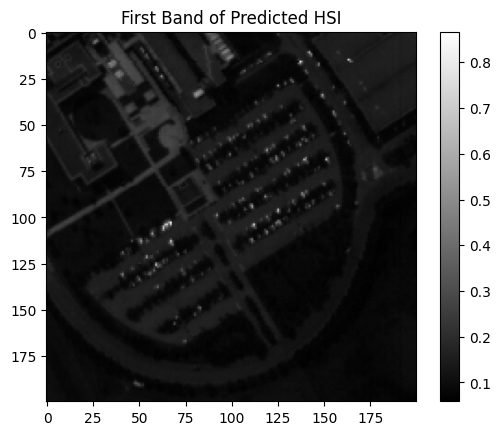

In [ ]:
import numpy as np
import rasterio
import tensorflow as tf
from tensorflow.keras.models import load_model
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ✅ Step 1: Define ECALayer (Custom Layer)
class ECALayer(tf.keras.layers.Layer):
    def __init__(self, k_size=5, **kwargs):
        super(ECALayer, self).__init__(**kwargs)
        self.k_size = k_size
        self.global_avg_pool = tf.keras.layers.GlobalAveragePooling2D(keepdims=True)
        self.conv1d = tf.keras.layers.Conv1D(filters=1, kernel_size=k_size, padding="same", activation="sigmoid", use_bias=False)

    def call(self, inputs):
        gap = self.global_avg_pool(inputs)
        gap_reshaped = tf.keras.layers.Reshape((-1, 1))(gap)
        attention = self.conv1d(gap_reshaped)
        attention = tf.keras.layers.Reshape((1, 1, -1))(attention)
        return inputs * attention

# ✅ Step 2: Load the Trained Model with Custom Objects
model_path = "/content/drive/MyDrive/model/trained_hyperspectral_model.h5"  # Update with your model path
model = load_model(model_path, custom_objects={"ECALayer": ECALayer}, compile=False)

print("✅ Model Loaded Successfully!")

# ✅ Step 3: Load the MSI Image for Prediction
msi_file = "/content/drive/MyDrive/model/HR_MSI_Image.tif"  # Update with your MSI file path

with rasterio.open(msi_file) as src:
    new_msi = src.read().astype(np.float32)
    new_msi = np.moveaxis(new_msi, 0, -1)
    profile = src.profile

print(f"✅ Loaded MSI Shape: {new_msi.shape}")  # (Height, Width, Bands)

# ✅ Step 4: Reduce MSI Bands to 4 (if needed)
expected_bands = 4
if new_msi.shape[-1] > expected_bands:
    print("⚠️ MSI has more bands than expected. Applying PCA to reduce...")
    reshaped_msi = new_msi.reshape(-1, new_msi.shape[-1])
    pca = PCA(n_components=expected_bands)
    reduced_msi = pca.fit_transform(reshaped_msi)
    new_msi = reduced_msi.reshape(new_msi.shape[0], new_msi.shape[1], expected_bands)
    print(f"✅ MSI Reduced to Shape: {new_msi.shape}")

# ✅ Step 5: Normalize the MSI (0-1 Scale)
new_msi /= np.max(new_msi)
print("✅ MSI is normalized (0 to 1)")

# ✅ Step 6: Extract MSI Patches for Prediction
patch_size = 4

def extract_patches(data, patch_size):
    patches = []
    for i in range(0, data.shape[0] - patch_size + 1, patch_size):
        for j in range(0, data.shape[1] - patch_size + 1, patch_size):
            patch = data[i:i + patch_size, j:j + patch_size, :]
            patches.append(patch)
    return np.array(patches)

test_msi_patches = extract_patches(new_msi, patch_size)
print(f"✅ Extracted MSI Patches Shape: {test_msi_patches.shape}")

# ✅ Step 7: Run Prediction with the Model
predicted_hsi_patches = model.predict(test_msi_patches)
print(f"✅ Predicted HSI Patches Shape: {predicted_hsi_patches.shape}")

# ✅ Step 8: Reconstruct Full HSI from Patches
def reconstruct_image(patches, img_shape, patch_size):
    full_hsi = np.zeros((img_shape[0], img_shape[1], patches.shape[-1]))
    patch_count = np.zeros((img_shape[0], img_shape[1], 1))

    idx = 0
    for i in range(0, img_shape[0] - patch_size + 1, patch_size):
        for j in range(0, img_shape[1] - patch_size + 1, patch_size):
            full_hsi[i:i + patch_size, j:j + patch_size, :] += patches[idx]
            patch_count[i:i + patch_size, j:j + patch_size, :] += 1
            idx += 1

    full_hsi /= np.maximum(patch_count, 1)
    return full_hsi

predicted_hsi = reconstruct_image(predicted_hsi_patches, new_msi.shape, patch_size)
print(f"✅ Reconstructed HSI Shape: {predicted_hsi.shape}")

# ✅ Step 9: Save the Predicted HSI as a GeoTIFF
output_hsi_path = "/content/drive/MyDrive/model/predicted_hsi.tif"

profile.update(
    dtype=rasterio.float32,
    count=predicted_hsi.shape[2]
)

with rasterio.open(output_hsi_path, 'w', **profile) as dst:
    for band in range(predicted_hsi.shape[2]):
        dst.write(predicted_hsi[:, :, band], band + 1)

print(f"✅ Predicted HSI saved as: {output_hsi_path}")

# ✅ Step 10: Visualize a Band of the Predicted HSI
plt.imshow(predicted_hsi[:, :, 0], cmap='gray')
plt.colorbar()
plt.title("First Band of Predicted HSI")
plt.show()


In [ ]:
import tensorflow as tf
import numpy as np
import scipy.io
import os
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------------------------- Parameter Settings --------------------------------------------------
patch_size = 8           # Input patch size
epoch = 50                # Number of training epochs
batch_size = 32           # Standard batch size
learning_rate_base = 0.01 # Initial learning rate

# -------------------------------------------------- Load Data --------------------------------------------------
print('Loading Data and Generating Training/Testing Samples...')

DATA_PATH = "/content/drive/MyDrive/model"

# Load Pavia University Hyperspectral Dataset
mat_data = scipy.io.loadmat(os.path.join(DATA_PATH, 'hydice_data.mat'))
HR_MSI = mat_data['msi_data']
HR_HSI = mat_data['hydhyper_data']
# there are no transpose lines for the bands here i need to write the transpose bands
  # Transpose to (H, W, C)


print(f"HR_MSI Shap111e After Fix: {HR_MSI.shape}")  # Should be (Height_HR, Width_HR, Band_MSI)
print(f"HR_HSI Shape After Fix: {HR_HSI.shape}")  # Should be (Height_HR, Width_HR, Band_HSI)

# Get image dimensions
Height_HR, Width_HR, Band_MSI = HR_MSI.shape
Band_HSI = HR_HSI.shape[2]



# Normalize Data
HR_MSI = HR_MSI.astype(np.float32) / np.max(HR_MSI)
HR_HSI = HR_HSI.astype(np.float32) / np.max(HR_HSI)

# -------------------------------------------------- Split Data into Training & Testing --------------------------------------------------
split_index = int(Width_HR * 0.7)  # 70% training, 30% testing
Training_MSI = HR_MSI[:, :split_index, :]
Training_HSI = HR_HSI[:, :split_index, :]
Testing_MSI = HR_MSI[:, split_index:, :]
Testing_HSI = HR_HSI[:, split_index:, :]

print(f"Training Data Shape: {Training_MSI.shape}, {Training_HSI.shape}")
print(f"Testing Data Shape: {Testing_MSI.shape}, {Testing_HSI.shape}")

# ✅ **Fix 1: Extract Training Patches Properly**
def extract_patches(data, patch_size):
    """ Extracts patches from hyperspectral images (batch, patch_size, patch_size, channels) """
    patches = []
    for i in range(0, data.shape[0] - patch_size + 1, patch_size):
        for j in range(0, data.shape[1] - patch_size + 1, patch_size):
            patch = data[i:i + patch_size, j:j + patch_size, :]
            patches.append(patch)
    return np.array(patches)

Train_MSI_Patches = extract_patches(Training_MSI, patch_size)
Train_HSI_Patches = extract_patches(Training_HSI, patch_size)
Test_MSI_Patches = extract_patches(Testing_MSI, patch_size)
Test_HSI_Patches = extract_patches(Testing_HSI, patch_size)

print(f"✅ Train MSI Shape: {Train_MSI_Patches.shape}, Train HSI Shape: {Train_HSI_Patches.shape}")
print(f"✅ Test MSI Shape: {Test_MSI_Patches.shape}, Test HSI Shape: {Test_HSI_Patches.shape}")

# -------------------------------------------------- Define Efficient Channel Attention (ECA) --------------------------------------------------
class ECALayer(tf.keras.layers.Layer):
    """ Efficient Channel Attention (ECA) as a Keras Layer """
    def __init__(self, k_size=5, **kwargs):
        super(ECALayer, self).__init__(**kwargs)
        self.k_size = k_size
        self.global_avg_pool = tf.keras.layers.GlobalAveragePooling2D(keepdims=True)
        self.conv1d = tf.keras.layers.Conv1D(filters=1, kernel_size=k_size, padding="same", activation="sigmoid", use_bias=False)

    def call(self, inputs):
        gap = self.global_avg_pool(inputs)  # Shape: (batch, 1, 1, channels)
        gap_reshaped = tf.keras.layers.Reshape((-1, 1))(gap)  # Shape: (batch, channels, 1)
        attention = self.conv1d(gap_reshaped)  # Apply Conv1D attention
        attention = tf.keras.layers.Reshape((1, 1, -1))(attention)  # Reshape back to (batch, 1, 1, channels)
        return inputs * attention  # Apply attention scaling

# -------------------------------------------------- Define the CNN Model with 3 Residual Blocks --------------------------------------------------
def build_model(input_shape, output_channels):
    inputs = tf.keras.Input(shape=input_shape)

    # 🔹 Initial 1x1 Convolution to match channels
    x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(inputs)

    # ✅ **Fix 2: Ensure skip connections match feature dimensions**
    shortcut = x

    # 🔹 Residual Block 1
    x1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x2 = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = tf.keras.layers.Concatenate()([x1, x2])
    x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = ECALayer(k_size=5)(x)
    x = tf.keras.layers.Add()([x, shortcut])  # Skip Connection

    # 🔹 Residual Block 2
    shortcut = x  # Update shortcut to the latest x
    x1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x2 = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = tf.keras.layers.Concatenate()([x1, x2])
    x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = ECALayer(k_size=5)(x)
    x = tf.keras.layers.Add()([x, shortcut])  # Skip Connection

    # 🔹 Residual Block 3
    shortcut = x  # Update shortcut again
    x1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x2 = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = tf.keras.layers.Concatenate()([x1, x2])
    x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = ECALayer(k_size=5)(x)
    x = tf.keras.layers.Add()([x, shortcut])  # Skip Connection

    # 🔹 Output Layer
    outputs = tf.keras.layers.Conv2D(output_channels, (1, 1), activation=None, padding='same')(x)
    outputs = ECALayer(k_size=5)(outputs)

    model = tf.keras.Model(inputs, outputs)
    return model

# -------------------------------------------------- Train the Model --------------------------------------------------
input_shape = (patch_size, patch_size, Band_MSI)
output_channels = Band_HSI

model = build_model(input_shape, output_channels)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate_base), loss='mse')

# ✅ **Fix 3: Pass Correctly Reshaped Training Data**
model.fit(Train_MSI_Patches, Train_HSI_Patches, batch_size=batch_size, epochs=epoch, validation_data=(Test_MSI_Patches, Test_HSI_Patches))

# Save Model
model.save("/content/drive/MyDrive/hyperiondata/trained_hyperspectral_model_hydice.h5")

print("✅ Model Training Complete & Saved!")



Loading Data and Generating Training/Testing Samples...
HR_MSI Shap111e After Fix: (1280, 307, 6)
HR_HSI Shape After Fix: (1280, 307, 191)
Training Data Shape: (1280, 214, 6), (1280, 214, 191)
Testing Data Shape: (1280, 93, 6), (1280, 93, 191)
✅ Train MSI Shape: (4160, 8, 8, 6), Train HSI Shape: (4160, 8, 8, 191)
✅ Test MSI Shape: (1760, 8, 8, 6), Test HSI Shape: (1760, 8, 8, 191)
Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0011 - val_loss: 2.3178e-05
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.6476e-05 - val_loss: 2.4559e-05
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.3361e-05 - val_loss: 1.7597e-05
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.1594e-05 - val_loss: 1.4769e-05
Epoch 5/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.1216e-06 - val_loss: 1.0597e-05
Epoch 6/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.5927e-06 - val_loss: 1.3615e-05
Epoch 7/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - l

✅ Model Training Complete & Saved!


✅ Model Loaded Successfully!
✅ Loaded MSI Shape: (1280, 307, 6)
✅ MSI is normalized (0 to 1)
✅ Extracted MSI Patches Shape: (6080, 8, 8, 6)
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
✅ Predicted HSI Patches Shape: (6080, 8, 8, 191)
✅ Reconstructed HSI Shape: (1280, 307, 191)
✅ Predicted HSI saved as: /content/drive/MyDrive/model/predicted_hsi_hydice.tif


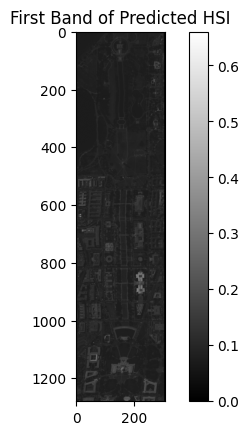

In [ ]:
import numpy as np
import rasterio
import tensorflow as tf
from tensorflow.keras.models import load_model
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ✅ Step 1: Define ECALayer (Custom Layer)
class ECALayer(tf.keras.layers.Layer):
    def __init__(self, k_size=5, **kwargs):
        super(ECALayer, self).__init__(**kwargs)
        self.k_size = k_size
        self.global_avg_pool = tf.keras.layers.GlobalAveragePooling2D(keepdims=True)
        self.conv1d = tf.keras.layers.Conv1D(filters=1, kernel_size=k_size, padding="same", activation="sigmoid", use_bias=False)

    def call(self, inputs):
        gap = self.global_avg_pool(inputs)
        gap_reshaped = tf.keras.layers.Reshape((-1, 1))(gap)
        attention = self.conv1d(gap_reshaped)
        attention = tf.keras.layers.Reshape((1, 1, -1))(attention)
        return inputs * attention

# ✅ Step 2: Load the Trained Model with Custom Objects
model_path = "/content/drive/MyDrive/hyperiondata/trained_hyperspectral_model_hydice.h5"  # Update with your model path
model = load_model(model_path, custom_objects={"ECALayer": ECALayer}, compile=False)

print("✅ Model Loaded Successfully!")

# ✅ Step 3: Load the MSI Image for Prediction
msi_file = "/content/drive/MyDrive/model/hydice_6_ms.tif"  # Update with your MSI file path

with rasterio.open(msi_file) as src:
    new_msi = src.read().astype(np.float32)
    new_msi = np.moveaxis(new_msi, 0, -1)
    profile = src.profile

print(f"✅ Loaded MSI Shape: {new_msi.shape}")  # (Height, Width, Bands)

# ✅ Step 4: Reduce MSI Bands to 4 (if needed)
expected_bands = 6
if new_msi.shape[-1] > expected_bands:
    print("⚠️ MSI has more bands than expected. Applying PCA to reduce...")
    reshaped_msi = new_msi.reshape(-1, new_msi.shape[-1])
    pca = PCA(n_components=expected_bands)
    reduced_msi = pca.fit_transform(reshaped_msi)
    new_msi = reduced_msi.reshape(new_msi.shape[0], new_msi.shape[1], expected_bands)
    print(f"✅ MSI Reduced to Shape: {new_msi.shape}")

# ✅ Step 5: Normalize the MSI (0-1 Scale)
new_msi /= np.max(new_msi)
print("✅ MSI is normalized (0 to 1)")

# ✅ Step 6: Extract MSI Patches for Prediction
patch_size = 8

def extract_patches(data, patch_size):
    patches = []
    for i in range(0, data.shape[0] - patch_size + 1, patch_size):
        for j in range(0, data.shape[1] - patch_size + 1, patch_size):
            patch = data[i:i + patch_size, j:j + patch_size, :]
            patches.append(patch)
    return np.array(patches)

test_msi_patches = extract_patches(new_msi, patch_size)
print(f"✅ Extracted MSI Patches Shape: {test_msi_patches.shape}")

# ✅ Step 7: Run Prediction with the Model
predicted_hsi_patches = model.predict(test_msi_patches)
print(f"✅ Predicted HSI Patches Shape: {predicted_hsi_patches.shape}")

# ✅ Step 8: Reconstruct Full HSI from Patches
def reconstruct_image(patches, img_shape, patch_size):
    full_hsi = np.zeros((img_shape[0], img_shape[1], patches.shape[-1]))
    patch_count = np.zeros((img_shape[0], img_shape[1], 1))

    idx = 0
    for i in range(0, img_shape[0] - patch_size + 1, patch_size):
        for j in range(0, img_shape[1] - patch_size + 1, patch_size):
            full_hsi[i:i + patch_size, j:j + patch_size, :] += patches[idx]
            patch_count[i:i + patch_size, j:j + patch_size, :] += 1
            idx += 1

    full_hsi /= np.maximum(patch_count, 1)
    return full_hsi

predicted_hsi = reconstruct_image(predicted_hsi_patches, new_msi.shape, patch_size)
print(f"✅ Reconstructed HSI Shape: {predicted_hsi.shape}")

# ✅ Step 9: Save the Predicted HSI as a GeoTIFF
output_hsi_path = "/content/drive/MyDrive/model/predicted_hsi_hydice.tif"

profile.update(
    dtype=rasterio.float32,
    count=predicted_hsi.shape[2]
)

with rasterio.open(output_hsi_path, 'w', **profile) as dst:
    for band in range(predicted_hsi.shape[2]):
        dst.write(predicted_hsi[:, :, band], band + 1)

print(f"✅ Predicted HSI saved as: {output_hsi_path}")

# ✅ Step 10: Visualize a Band of the Predicted HSI
plt.imshow(predicted_hsi[:, :, 8], cmap='grey')
plt.colorbar()
plt.title("First Band of Predicted HSI")
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import scipy.io
import os
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------------------------- Parameter Settings --------------------------------------------------
patch_size = 8           # Input patch size
epoch = 50                # Number of training epochs
batch_size = 32           # Standard batch size
learning_rate_base = 0.01 # Initial learning rate

# -------------------------------------------------- Load Data --------------------------------------------------
print('Loading Data and Generating Training/Testing Samples...')

DATA_PATH = "/content/drive/MyDrive/model"

# Load Pavia University Hyperspectral Dataset
mat_data = scipy.io.loadmat(os.path.join(DATA_PATH, 'new-dataset(ali-hyperion).mat'))
HR_MSI = mat_data['msi_data']
HR_HSI = mat_data['hyper_data']
# there are no transpose lines for the bands here i need to write the transpose bands
  # Transpose to (H, W, C)


print(f"HR_MSI Shap111e After Fix: {HR_MSI.shape}")  # Should be (Height_HR, Width_HR, Band_MSI)
print(f"HR_HSI Shape After Fix: {HR_HSI.shape}")  # Should be (Height_HR, Width_HR, Band_HSI)

# Get image dimensions
Height_HR, Width_HR, Band_MSI = HR_MSI.shape
Band_HSI = HR_HSI.shape[2]



# Normalize Data
HR_MSI = HR_MSI.astype(np.float32) / np.max(HR_MSI)
HR_HSI = HR_HSI.astype(np.float32) / np.max(HR_HSI)

# -------------------------------------------------- Split Data into Training & Testing --------------------------------------------------
split_index = int(Width_HR * 0.7)  # 70% training, 30% testing
Training_MSI = HR_MSI[:, :split_index, :]
Training_HSI = HR_HSI[:, :split_index, :]
Testing_MSI = HR_MSI[:, split_index:, :]
Testing_HSI = HR_HSI[:, split_index:, :]

print(f"Training Data Shape: {Training_MSI.shape}, {Training_HSI.shape}")
print(f"Testing Data Shape: {Testing_MSI.shape}, {Testing_HSI.shape}")

# ✅ **Fix 1: Extract Training Patches Properly**
def extract_patches(data, patch_size):
    """ Extracts patches from hyperspectral images (batch, patch_size, patch_size, channels) """
    patches = []
    for i in range(0, data.shape[0] - patch_size + 1, patch_size):
        for j in range(0, data.shape[1] - patch_size + 1, patch_size):
            patch = data[i:i + patch_size, j:j + patch_size, :]
            patches.append(patch)
    return np.array(patches)

Train_MSI_Patches = extract_patches(Training_MSI, patch_size)
Train_HSI_Patches = extract_patches(Training_HSI, patch_size)
Test_MSI_Patches = extract_patches(Testing_MSI, patch_size)
Test_HSI_Patches = extract_patches(Testing_HSI, patch_size)

print(f"✅ Train MSI Shape: {Train_MSI_Patches.shape}, Train HSI Shape: {Train_HSI_Patches.shape}")
print(f"✅ Test MSI Shape: {Test_MSI_Patches.shape}, Test HSI Shape: {Test_HSI_Patches.shape}")

# -------------------------------------------------- Define Efficient Channel Attention (ECA) --------------------------------------------------
class ECALayer(tf.keras.layers.Layer):
    """ Efficient Channel Attention (ECA) as a Keras Layer """
    def __init__(self, k_size=5, **kwargs):
        super(ECALayer, self).__init__(**kwargs)
        self.k_size = k_size
        self.global_avg_pool = tf.keras.layers.GlobalAveragePooling2D(keepdims=True)
        self.conv1d = tf.keras.layers.Conv1D(filters=1, kernel_size=k_size, padding="same", activation="sigmoid", use_bias=False)

    def call(self, inputs):
        gap = self.global_avg_pool(inputs)  # Shape: (batch, 1, 1, channels)
        gap_reshaped = tf.keras.layers.Reshape((-1, 1))(gap)  # Shape: (batch, channels, 1)
        attention = self.conv1d(gap_reshaped)  # Apply Conv1D attention
        attention = tf.keras.layers.Reshape((1, 1, -1))(attention)  # Reshape back to (batch, 1, 1, channels)
        return inputs * attention  # Apply attention scaling

# -------------------------------------------------- Define the CNN Model with 3 Residual Blocks --------------------------------------------------
def build_model(input_shape, output_channels):
    inputs = tf.keras.Input(shape=input_shape)

    # 🔹 Initial 1x1 Convolution to match channels
    x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(inputs)

    # ✅ **Fix 2: Ensure skip connections match feature dimensions**
    shortcut = x

    # 🔹 Residual Block 1
    x1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x2 = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = tf.keras.layers.Concatenate()([x1, x2])
    x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = ECALayer(k_size=5)(x)
    x = tf.keras.layers.Add()([x, shortcut])  # Skip Connection

    # 🔹 Residual Block 2
    shortcut = x  # Update shortcut to the latest x
    x1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x2 = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = tf.keras.layers.Concatenate()([x1, x2])
    x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = ECALayer(k_size=5)(x)
    x = tf.keras.layers.Add()([x, shortcut])  # Skip Connection

    # 🔹 Residual Block 3
    shortcut = x  # Update shortcut again
    x1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x2 = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = tf.keras.layers.Concatenate()([x1, x2])
    x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
    x = ECALayer(k_size=5)(x)
    x = tf.keras.layers.Add()([x, shortcut])  # Skip Connection

    # 🔹 Output Layer
    outputs = tf.keras.layers.Conv2D(output_channels, (1, 1), activation=None, padding='same')(x)
    outputs = ECALayer(k_size=5)(outputs)

    model = tf.keras.Model(inputs, outputs)
    return model

# -------------------------------------------------- Train the Model --------------------------------------------------
input_shape = (patch_size, patch_size, Band_MSI)
output_channels = Band_HSI

model = build_model(input_shape, output_channels)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate_base), loss='mse')

# ✅ **Fix 3: Pass Correctly Reshaped Training Data**
model.fit(Train_MSI_Patches, Train_HSI_Patches, batch_size=batch_size, epochs=epoch, validation_data=(Test_MSI_Patches, Test_HSI_Patches))

# Save Model
model.save("/content/drive/MyDrive/hyperion/trained_hyperspectral_model.h5")

print("✅ Model Training Complete & Saved!")
#---------------------------------------------------------------
# ✅ Evaluate Model Accuracy
from sklearn.metrics import mean_squared_error
from math import log10
import numpy as np

# Predict on Test MSI Patches
predicted_HSI = model.predict(Test_MSI_Patches)

# Flatten for comparison
y_true = Test_HSI_Patches.reshape(-1, Band_HSI)
y_pred = predicted_HSI.reshape(-1, Band_HSI)

# RMSE
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
print(f"🔹 RMSE (Root Mean Squared Error): {rmse:.4f}")

# PSNR
mse = np.mean((y_true - y_pred) ** 2)
if mse == 0:
    psnr = float('inf')
else:
    psnr = 20 * log10(1.0 / np.sqrt(mse))  # Assumes normalized data in [0,1]
print(f"🔹 PSNR (Peak Signal-to-Noise Ratio): {psnr:.2f} dB")

# Optional: Percentage Accuracy (as 1 - Normalized RMSE)
normalized_rmse = rmse / (np.max(y_true) - np.min(y_true))
accuracy = (1 - normalized_rmse) * 100
print(f"✅ Overall Approximate Accuracy: {accuracy:.2f}%")


Loading Data and Generating Training/Testing Samples...
HR_MSI Shap111e After Fix: (196, 196, 8)
HR_HSI Shape After Fix: (196, 196, 178)
Training Data Shape: (196, 137, 8), (196, 137, 178)
Testing Data Shape: (196, 59, 8), (196, 59, 178)
✅ Train MSI Shape: (408, 8, 8, 8), Train HSI Shape: (408, 8, 8, 178)
✅ Test MSI Shape: (168, 8, 8, 8), Test HSI Shape: (168, 8, 8, 178)
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 396ms/step - loss: 0.0360 - val_loss: 0.0048
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0037 - val_loss: 0.0025
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0015 - val_loss: 0.0019
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.6765e-04 - val_loss: 0.0015
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7.1863e-04 - val_loss: 0.0013
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.3435e-04 - val_loss: 0.0011
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.1999e-04 - val_loss: 8.7630e-04
Epoch 8/5

✅ Model Training Complete & Saved!
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step
🔹 RMSE (Root Mean Squared Error): 0.0142
🔹 PSNR (Peak Signal-to-Noise Ratio): 36.97 dB
✅ Overall Approximate Accuracy: 98.58%


✅ Model Loaded Successfully!


✅ Loaded MSI Shape: (196, 196, 8)
✅ MSI is normalized (0 to 1)
✅ Extracted MSI Patches Shape: (576, 8, 8, 8)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  
✅ Predicted HSI Patches Shape: (576, 8, 8, 178)
✅ Reconstructed HSI Shape: (196, 196, 178)
✅ Predicted HSI saved as: /content/drive/MyDrive/model/predicted_hsi.tif


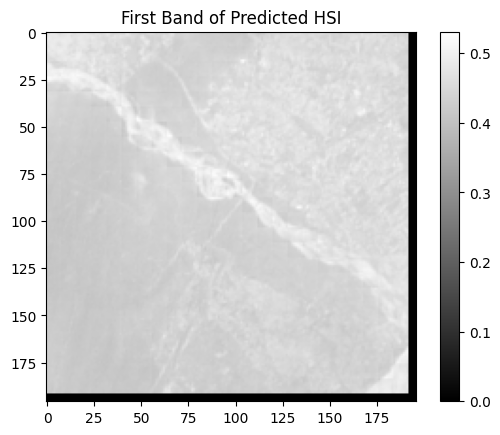

In [ ]:
import numpy as np
import rasterio
import tensorflow as tf
from tensorflow.keras.models import load_model
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ✅ Step 1: Define ECALayer (Custom Layer)
class ECALayer(tf.keras.layers.Layer):
    def __init__(self, k_size=5, **kwargs):
        super(ECALayer, self).__init__(**kwargs)
        self.k_size = k_size
        self.global_avg_pool = tf.keras.layers.GlobalAveragePooling2D(keepdims=True)
        self.conv1d = tf.keras.layers.Conv1D(filters=1, kernel_size=k_size, padding="same", activation="sigmoid", use_bias=False)

    def call(self, inputs):
        gap = self.global_avg_pool(inputs)
        gap_reshaped = tf.keras.layers.Reshape((-1, 1))(gap)
        attention = self.conv1d(gap_reshaped)
        attention = tf.keras.layers.Reshape((1, 1, -1))(attention)
        return inputs * attention

# ✅ Step 2: Load the Trained Model with Custom Objects
model_path = "/content/drive/MyDrive/hyperion/trained_hyperspectral_model.h5"  # Update with your model path
model = load_model(model_path, custom_objects={"ECALayer": ECALayer}, compile=False)

print("✅ Model Loaded Successfully!")

# ✅ Step 3: Load the MSI Image for Prediction
msi_file = "/content/drive/MyDrive/model/newali22.tif"  # Update with your MSI file path

with rasterio.open(msi_file) as src:
    new_msi = src.read().astype(np.float32)
    new_msi = np.moveaxis(new_msi, 0, -1)
    profile = src.profile

print(f"✅ Loaded MSI Shape: {new_msi.shape}")  # (Height, Width, Bands)

# ✅ Step 4: Reduce MSI Bands to 4 (if needed)
expected_bands = 8
if new_msi.shape[-1] > expected_bands:
    print("⚠️ MSI has more bands than expected. Applying PCA to reduce...")
    reshaped_msi = new_msi.reshape(-1, new_msi.shape[-1])
    pca = PCA(n_components=expected_bands)
    reduced_msi = pca.fit_transform(reshaped_msi)
    new_msi = reduced_msi.reshape(new_msi.shape[0], new_msi.shape[1], expected_bands)
    print(f"✅ MSI Reduced to Shape: {new_msi.shape}")

# ✅ Step 5: Normalize the MSI (0-1 Scale)
new_msi /= np.max(new_msi)
print("✅ MSI is normalized (0 to 1)")

# ✅ Step 6: Extract MSI Patches for Prediction
patch_size = 8

def extract_patches(data, patch_size):
    patches = []
    for i in range(0, data.shape[0] - patch_size + 1, patch_size):
        for j in range(0, data.shape[1] - patch_size + 1, patch_size):
            patch = data[i:i + patch_size, j:j + patch_size, :]
            patches.append(patch)
    return np.array(patches)

test_msi_patches = extract_patches(new_msi, patch_size)
print(f"✅ Extracted MSI Patches Shape: {test_msi_patches.shape}")

# ✅ Step 7: Run Prediction with the Model
predicted_hsi_patches = model.predict(test_msi_patches)
print(f"✅ Predicted HSI Patches Shape: {predicted_hsi_patches.shape}")

# ✅ Step 8: Reconstruct Full HSI from Patches
def reconstruct_image(patches, img_shape, patch_size):
    full_hsi = np.zeros((img_shape[0], img_shape[1], patches.shape[-1]))
    patch_count = np.zeros((img_shape[0], img_shape[1], 1))

    idx = 0
    for i in range(0, img_shape[0] - patch_size + 1, patch_size):
        for j in range(0, img_shape[1] - patch_size + 1, patch_size):
            full_hsi[i:i + patch_size, j:j + patch_size, :] += patches[idx]
            patch_count[i:i + patch_size, j:j + patch_size, :] += 1
            idx += 1

    full_hsi /= np.maximum(patch_count, 1)
    return full_hsi

predicted_hsi = reconstruct_image(predicted_hsi_patches, new_msi.shape, patch_size)
print(f"✅ Reconstructed HSI Shape: {predicted_hsi.shape}")

# ✅ Step 9: Save the Predicted HSI as a GeoTIFF
output_hsi_path = "/content/drive/MyDrive/model/predicted_hsi.tif"

profile.update(
    dtype=rasterio.float32,
    count=predicted_hsi.shape[2]
)

with rasterio.open(output_hsi_path, 'w', **profile) as dst:
    for band in range(predicted_hsi.shape[2]):
        dst.write(predicted_hsi[:, :, band], band + 1)

print(f"✅ Predicted HSI saved as: {output_hsi_path}")

# ✅ Step 10: Visualize a Band of the Predicted HSI
plt.imshow(predicted_hsi[:, :, 0], cmap='grey')
plt.colorbar()
plt.title("First Band of Predicted HSI")
plt.show()

# ---------------------------**--hydice**:----------------------------------------------

In [ ]:
!pip install scikit-image



# -------------------ENTROPY CALCULATION---------------------------------

✅ Loaded HSI shape: (196, 196, 196)
Min: 1.0000, Max: 7178.0000, Mean: 1192.3525


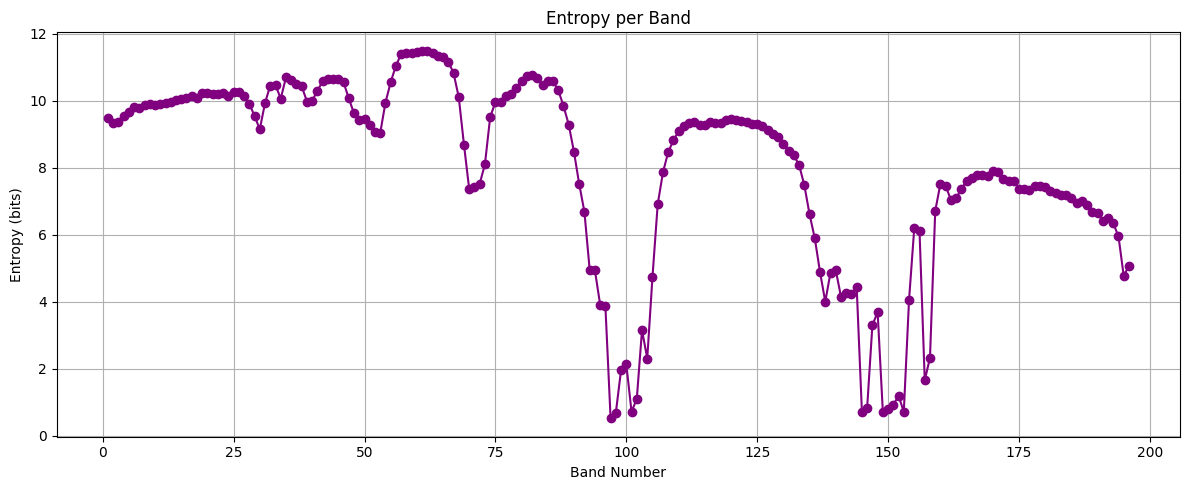

🧠 Overall entropy of the HSI cube: 10.6776 bits


In [ ]:
import numpy as np
import rasterio
from skimage.measure import shannon_entropy
import matplotlib.pyplot as plt

# ✅ Load HSI image
hsi_path = "/content/drive/MyDrive/model/new12.tif"
with rasterio.open(hsi_path) as src:
    hsi = src.read().astype(np.float32)  # (Bands, H, W)
    hsi = np.moveaxis(hsi, 0, -1)        # (H, W, Bands)

print(f"✅ Loaded HSI shape: {hsi.shape}")
print(f"Min: {np.min(hsi):.4f}, Max: {np.max(hsi):.4f}, Mean: {np.mean(hsi):.4f}")

# ✅ Function to calculate entropy for a 2D image/band
def compute_entropy(image_2d):
    img_min = image_2d.min()
    img_max = image_2d.max()
    if img_max - img_min == 0:
        return 0.0
    norm = (image_2d - img_min) / (img_max - img_min)
    norm_uint16 = (norm * 65535).astype(np.uint16)
    return shannon_entropy(norm_uint16)

# ✅ Compute entropy for each band
entropy_per_band = []
for i in range(hsi.shape[-1]):
    band_entropy = compute_entropy(hsi[:, :, i])
    entropy_per_band.append(band_entropy)

# ✅ Plot entropy per band
plt.figure(figsize=(12, 5))
plt.plot(range(1, len(entropy_per_band)+1), entropy_per_band, marker='o', color='purple')
plt.title("Entropy per Band")
plt.xlabel("Band Number")
plt.ylabel("Entropy (bits)")
plt.grid(True)
plt.tight_layout()
plt.show()


# ✅ Compute overall entropy of the entire HSI cube
# Flatten and normalize the full HSI cube
hsi_flat = hsi.flatten()
hsi_min = hsi_flat.min()
hsi_max = hsi_flat.max()

if hsi_max - hsi_min == 0:
    overall_entropy = 0.0
else:
    hsi_norm = (hsi_flat - hsi_min) / (hsi_max - hsi_min)
    hsi_uint16 = (hsi_norm * 65535).astype(np.uint16)
    overall_entropy = shannon_entropy(hsi_uint16)

print(f"🧠 Overall entropy of the HSI cube: {overall_entropy:.4f} bits")


✅ Loaded HSI shape: (196, 196, 196)
Min: -0.0029, Max: 1.0627, Mean: 0.1769


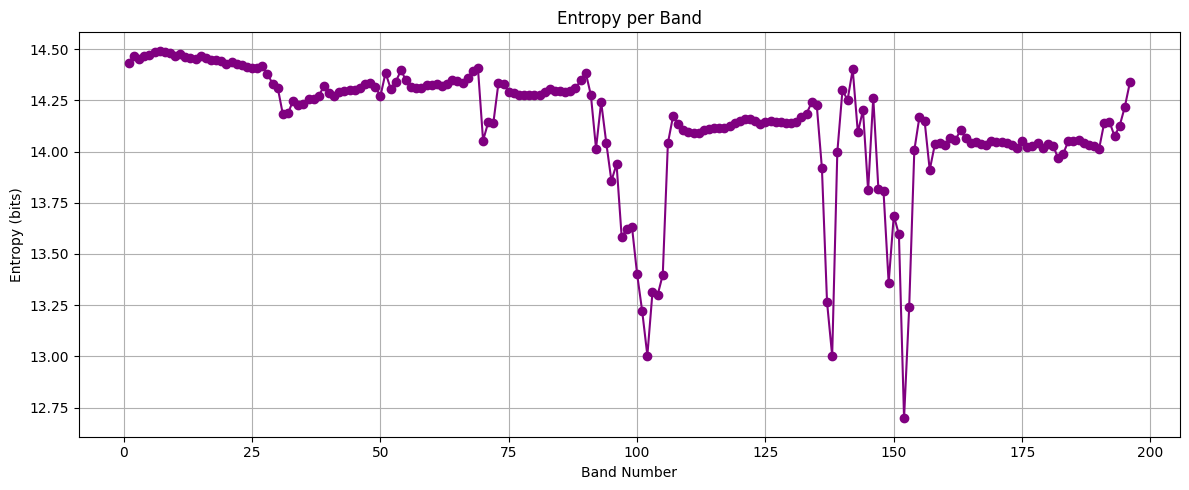

📊 Average entropy across all bands: 14.1435 bits


In [ ]:
import numpy as np
import rasterio
from skimage.measure import shannon_entropy
import matplotlib.pyplot as plt

# ✅ Load HSI image
hsi_path = "/content/drive/MyDrive/model/predicted_hsi.tif"
with rasterio.open(hsi_path) as src:
    hsi = src.read().astype(np.float32)  # (Bands, H, W)
    hsi = np.moveaxis(hsi, 0, -1)        # (H, W, Bands)

print(f"✅ Loaded HSI shape: {hsi.shape}")
print(f"Min: {np.min(hsi):.4f}, Max: {np.max(hsi):.4f}, Mean: {np.mean(hsi):.4f}")

# ✅ Function to calculate entropy for a 2D image/band
def compute_entropy(image_2d):
    # Min-max normalization to [0, 65535]
    img_min = image_2d.min()
    img_max = image_2d.max()
    if img_max - img_min == 0:
        return 0.0  # Flat image, zero entropy
    norm = (image_2d - img_min) / (img_max - img_min)
    norm_uint16 = (norm * 65535).astype(np.uint16)
    return shannon_entropy(norm_uint16)

# ✅ Compute entropy for each band
entropy_per_band = []
for i in range(hsi.shape[-1]):
    band_entropy = compute_entropy(hsi[:, :, i])
    entropy_per_band.append(band_entropy)

# ✅ Plot entropy per band
plt.figure(figsize=(12, 5))
plt.plot(range(1, len(entropy_per_band)+1), entropy_per_band, marker='o', color='purple')
plt.title("Entropy per Band")
plt.xlabel("Band Number")
plt.ylabel("Entropy (bits)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ✅ Overall average entropy
mean_entropy = np.mean(entropy_per_band)
print(f"📊 Average entropy across all bands: {mean_entropy:.4f} bits")


✅ Loaded HSI shape: (610, 340, 103)
Min: 0.0000, Max: 8000.0000, Mean: 1389.1246


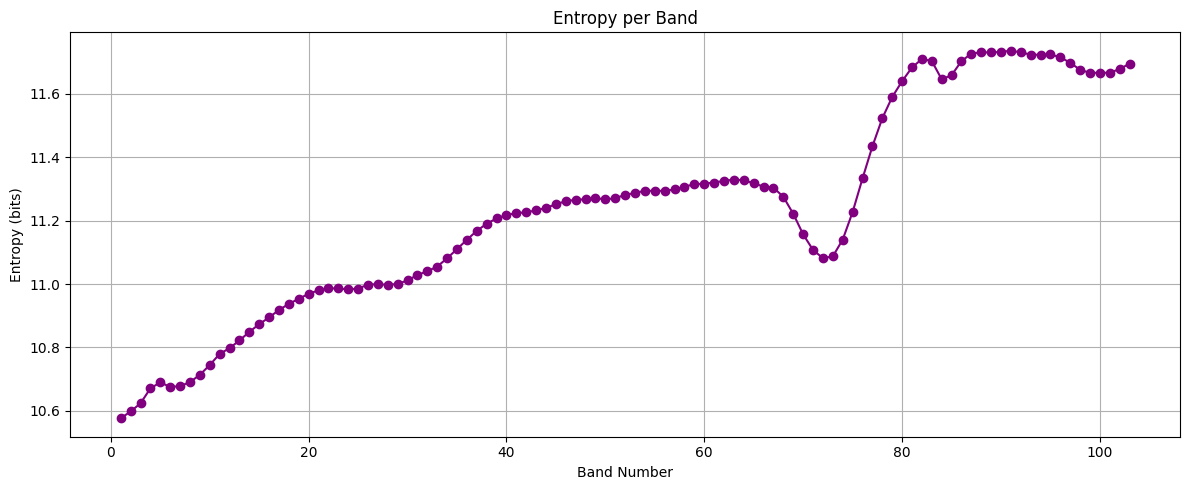

🧠 Overall entropy of the HSI cube: 11.6527 bits


In [ ]:
import numpy as np
import rasterio
from skimage.measure import shannon_entropy
import matplotlib.pyplot as plt

# ✅ Load HSI image
hsi_path = "/content/drive/MyDrive/model/predicted_hsi-pavia.tif"
with rasterio.open(hsi_path) as src:
    hsi = src.read().astype(np.float32)  # (Bands, H, W)
    hsi = np.moveaxis(hsi, 0, -1)        # (H, W, Bands)

print(f"✅ Loaded HSI shape: {hsi.shape}")
print(f"Min: {np.min(hsi):.4f}, Max: {np.max(hsi):.4f}, Mean: {np.mean(hsi):.4f}")

# ✅ Function to calculate entropy for a 2D image/band
def compute_entropy(image_2d):
    img_min = image_2d.min()
    img_max = image_2d.max()
    if img_max - img_min == 0:
        return 0.0
    norm = (image_2d - img_min) / (img_max - img_min)
    norm_uint16 = (norm * 65535).astype(np.uint16)
    return shannon_entropy(norm_uint16)

# ✅ Compute entropy for each band
entropy_per_band = []
for i in range(hsi.shape[-1]):
    band_entropy = compute_entropy(hsi[:, :, i])
    entropy_per_band.append(band_entropy)

# ✅ Plot entropy per band
plt.figure(figsize=(12, 5))
plt.plot(range(1, len(entropy_per_band)+1), entropy_per_band, marker='o', color='purple')
plt.title("Entropy per Band")
plt.xlabel("Band Number")
plt.ylabel("Entropy (bits)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ✅ Compute overall entropy of the entire HSI cube
# Flatten and normalize the full HSI cube
hsi_flat = hsi.flatten()
hsi_min = hsi_flat.min()
hsi_max = hsi_flat.max()

if hsi_max - hsi_min == 0:
    overall_entropy = 0.0
else:
    hsi_norm = (hsi_flat - hsi_min) / (hsi_max - hsi_min)
    hsi_uint16 = (hsi_norm * 65535).astype(np.uint16)
    overall_entropy = shannon_entropy(hsi_uint16)

print(f"🧠 Overall entropy of the HSI cube: {overall_entropy:.4f} bits")


## --------------SNR --------ANALYSIS--------------------------------------

# `-----------------SPECTRAL SIMULARITY INDEX CALCULATION---------------------`

*italicized text*-------------------------STRUCTRAL SIMULARITY INDEX CALCULATION------------------------------------

In [ ]:
import numpy as np
from skimage.io import imread
import cv2

def ssim_index(img1, img2, K=(0.01, 0.03), window_size=11, sigma=1.5, L=255):
    if img1.shape != img2.shape:
        raise ValueError("Input images must have the same dimensions.")

    if len(img1.shape) > 2 and img1.shape[2] != 1:
        raise ValueError("Please provide grayscale or single-channel images.")

    window = cv2.getGaussianKernel(window_size, sigma)
    window = window @ window.T
    window = window / np.sum(window)

    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    mu1 = cv2.filter2D(img1, -1, window)
    mu2 = cv2.filter2D(img2, -1, window)

    mu1_sq = mu1 * mu1
    mu2_sq = mu2 * mu2
    mu1_mu2 = mu1 * mu2

    sigma1_sq = cv2.filter2D(img1 * img1, -1, window) - mu1_sq
    sigma2_sq = cv2.filter2D(img2 * img2, -1, window) - mu2_sq
    sigma12 = cv2.filter2D(img1 * img2, -1, window) - mu1_mu2

    C1 = (K[0] * L) ** 2
    C2 = (K[1] * L) ** 2

    numerator1 = 2 * mu1_mu2 + C1
    numerator2 = 2 * sigma12 + C2
    denominator1 = mu1_sq + mu2_sq + C1
    denominator2 = sigma1_sq + sigma2_sq + C2

    ssim_map = (numerator1 * numerator2) / (denominator1 * denominator2)
    mssim = ssim_map.mean()
    return mssim, ssim_map

def cal_ssim(im1, im2, b_row, b_col):
    h, w = im1.shape[:2]
    if im1.ndim == 2:  # Grayscale
        return ssim_index(im1[b_row:h-b_row, b_col:w-b_col], im2[b_row:h-b_row, b_col:w-b_col])[0]
    elif im1.ndim == 3:  # RGB or multi-band
        ssim_total = 0
        bands = im1.shape[2]
        for i in range(bands):
            sub1 = im1[b_row:h-b_row, b_col:w-b_col, i]
            sub2 = im2[b_row:h-b_row, b_col:w-b_col, i]
            ssim_total += ssim_index(sub1, sub2)[0]
        return ssim_total / bands
    else:
        raise ValueError("Unsupported image shape")

# Example usage
if __name__ == "__main__":
    # Load .tif images using skimage (works with multi-band)
    img1 = imread('/content/drive/MyDrive/model/hyperion_HSI_178bands.tif')
    img2 = imread('/content/drive/MyDrive/model/predicted_hsi.tif')

    if img1 is None or img2 is None:
        raise FileNotFoundError("Image path is incorrect.")

    # Convert to uint8 if needed (for visualization or L=255)
    if img1.dtype != np.uint8:
        img1 = ((img1 - np.min(img1)) / (np.max(img1) - np.min(img1)) * 255).astype(np.uint8)
    if img2.dtype != np.uint8:
        img2 = ((img2 - np.min(img2)) / (np.max(img2) - np.min(img2)) * 255).astype(np.uint8)

    # Ensure same shape
    min_shape = tuple(map(min, zip(img1.shape, img2.shape)))
    img1 = img1[:min_shape[0], :min_shape[1], ...]
    img2 = img2[:min_shape[0], :min_shape[1], ...]

    b_row, b_col = 5, 5  # Padding
    result = cal_ssim(img1, img2, b_row, b_col)
    print("SSIM:", result)


SSIM: 0.8648539485705606


✅ Model Loaded Successfully!
✅ Loaded MSI Shape: (1003, 1044, 4)
✅ MSI Ready Shape: (1003, 1044, 4)
✅ MSI normalized (0–1 scale)
✅ Extracted MSI Patches Shape: (65250, 4, 4, 4)
2040/2040 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step
✅ Predicted HSI Patches Shape: (65250, 4, 4, 103)
✅ Reconstructed HSI Shape: (1003, 1044, 103)
✅ Predicted HSI saved at: /content/drive/MyDrive/model/sentinal_hsi.tif


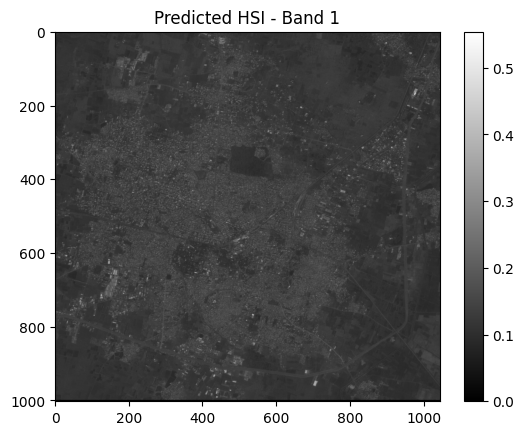

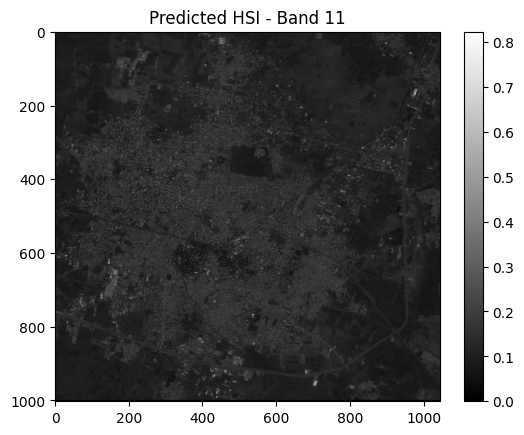

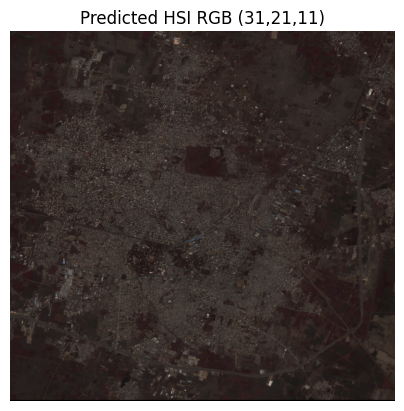

In [ ]:
import numpy as np
import rasterio
import tensorflow as tf
from tensorflow.keras.models import load_model
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ✅ Step 1: Define ECALayer (Custom Layer)
class ECALayer(tf.keras.layers.Layer):
    def __init__(self, k_size=5, **kwargs):
        super(ECALayer, self).__init__(**kwargs)
        self.k_size = k_size
        self.global_avg_pool = tf.keras.layers.GlobalAveragePooling2D(keepdims=True)
        self.conv1d = tf.keras.layers.Conv1D(filters=1, kernel_size=k_size,
                                             padding="same", activation="sigmoid", use_bias=False)

    def call(self, inputs):
        gap = self.global_avg_pool(inputs)  # (batch, 1, 1, channels)
        gap_reshaped = tf.keras.layers.Reshape((-1, 1))(gap)
        attention = self.conv1d(gap_reshaped)
        attention = tf.keras.layers.Reshape((1, 1, -1))(attention)
        return inputs * attention

# ✅ Step 2: Load Trained Model
model_path = "/content/drive/MyDrive/model/trained_hyperspectral_model.h5"
model = load_model(model_path, custom_objects={"ECALayer": ECALayer}, compile=False)
print("✅ Model Loaded Successfully!")

# ✅ Step 3: Load MSI Image
msi_file = "/content/drive/MyDrive/superdataset/S2_HR/Guntur_S2_2019-01-01_0.tif"
with rasterio.open(msi_file) as src:
    new_msi = src.read().astype(np.float32)   # (bands, H, W)
    new_msi = np.moveaxis(new_msi, 0, -1)     # (H, W, bands)
    profile = src.profile

print(f"✅ Loaded MSI Shape: {new_msi.shape}")  # (Height, Width, Bands)

# ✅ Step 4: Ensure MSI Bands Match Model Input
expected_bands = 4   # adjust based on your model
if new_msi.shape[-1] > expected_bands:
    print(f"⚠️ MSI has {new_msi.shape[-1]} bands, reducing to {expected_bands} using PCA...")
    reshaped_msi = new_msi.reshape(-1, new_msi.shape[-1])
    pca = PCA(n_components=expected_bands)
    reduced_msi = pca.fit_transform(reshaped_msi)
    new_msi = reduced_msi.reshape(new_msi.shape[0], new_msi.shape[1], expected_bands)
elif new_msi.shape[-1] < expected_bands:
    raise ValueError(f"❌ Input MSI has {new_msi.shape[-1]} bands, but model expects {expected_bands}")

print(f"✅ MSI Ready Shape: {new_msi.shape}")

# ✅ Step 5: Normalize to [0,1]
new_msi = new_msi / np.max(new_msi)
print("✅ MSI normalized (0–1 scale)")

# ✅ Step 6: Extract MSI Patches
patch_size = 4   # must match model training
def extract_patches(data, patch_size):
    patches = []
    for i in range(0, data.shape[0] - patch_size + 1, patch_size):
        for j in range(0, data.shape[1] - patch_size + 1, patch_size):
            patch = data[i:i + patch_size, j:j + patch_size, :]
            patches.append(patch)
    return np.array(patches)

test_msi_patches = extract_patches(new_msi, patch_size)
print(f"✅ Extracted MSI Patches Shape: {test_msi_patches.shape}")

# ✅ Step 7: Run Prediction
predicted_hsi_patches = model.predict(test_msi_patches, verbose=1)
print(f"✅ Predicted HSI Patches Shape: {predicted_hsi_patches.shape}")

# ✅ Step 8: Reconstruct Full HSI
def reconstruct_image(patches, img_shape, patch_size):
    full_hsi = np.zeros((img_shape[0], img_shape[1], patches.shape[-1]))
    patch_count = np.zeros((img_shape[0], img_shape[1], 1))
    idx = 0
    for i in range(0, img_shape[0] - patch_size + 1, patch_size):
        for j in range(0, img_shape[1] - patch_size + 1, patch_size):
            full_hsi[i:i + patch_size, j:j + patch_size, :] += patches[idx]
            patch_count[i:i + patch_size, j:j + patch_size, :] += 1
            idx += 1
    full_hsi /= np.maximum(patch_count, 1)
    return full_hsi

predicted_hsi = reconstruct_image(predicted_hsi_patches, new_msi.shape, patch_size)
print(f"✅ Reconstructed HSI Shape: {predicted_hsi.shape}")

# ✅ Step 9: Save Predicted HSI (Optimized for QGIS & ENVI)
output_hsi_path = "/content/drive/MyDrive/model/sentinal_hsi.tif"

profile.update(
    dtype=rasterio.float32,
    count=predicted_hsi.shape[2],
    compress="lzw",         # lossless compression
    tiled=True,             # enables internal tiling
    blockxsize=256,         # tile width
    blockysize=256          # tile height
)

with rasterio.open(output_hsi_path, 'w', **profile) as dst:
    for band in range(predicted_hsi.shape[2]):
        dst.write(predicted_hsi[:, :, band], band + 1)

print(f"✅ Predicted HSI saved at: {output_hsi_path}")


# ✅ Step 10: Flexible Visualization
def show_band(hsi, band_idx):
    """Show single band"""
    if band_idx < 0 or band_idx >= hsi.shape[2]:
        raise ValueError(f"Invalid band index {band_idx}. Available 0–{hsi.shape[2]-1}")
    plt.imshow(hsi[:, :, band_idx], cmap="gray")
    plt.colorbar()
    plt.title(f"Predicted HSI - Band {band_idx+1}")
    plt.show()

def show_rgb(hsi, r, g, b, stretch=True):
    """Show RGB composite"""
    if max(r, g, b) >= hsi.shape[2]:
        raise ValueError(f"Invalid RGB bands {r,g,b}. Available 0–{hsi.shape[2]-1}")
    rgb = np.stack([hsi[:, :, r], hsi[:, :, g], hsi[:, :, b]], axis=-1)
    if stretch:
        rgb = (rgb - np.min(rgb)) / (np.max(rgb) - np.min(rgb) + 1e-8)
    plt.imshow(rgb)
    plt.title(f"Predicted HSI RGB ({r+1},{g+1},{b+1})")
    plt.axis("off")
    plt.show()

# 🔍 Examples:
show_band(predicted_hsi, 0)          # First band
show_band(predicted_hsi, 10)         # Band 11
show_rgb(predicted_hsi, 30, 20, 10)  # RGB composite


In [ ]:
import numpy as np
import rasterio
import tensorflow as tf
from tensorflow.keras.models import load_model
import os
from osgeo import gdal
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from skimage.util import view_as_windows
from tqdm import tqdm

# ✅ Step 1: Define ECALayer (Custom Layer)
class ECALayer(tf.keras.layers.Layer):
    def __init__(self, k_size=5, **kwargs):
        super(ECALayer, self).__init__(**kwargs)
        self.k_size = k_size
        self.global_avg_pool = tf.keras.layers.GlobalAveragePooling2D(keepdims=True)
        self.conv1d = tf.keras.layers.Conv1D(filters=1, kernel_size=k_size,
                                             padding="same", activation="sigmoid", use_bias=False)

    def call(self, inputs):
        gap = self.global_avg_pool(inputs)  # (batch, 1, 1, channels)
        gap_reshaped = tf.keras.layers.Reshape((-1, 1))(gap)
        attention = self.conv1d(gap_reshaped)
        attention = tf.keras.layers.Reshape((1, 1, -1))(attention)
        return inputs * attention

# ✅ Step 2: Load Trained Model
model_path = "/content/drive/MyDrive/model/trained_hyperspectral_model.h5"
if not os.path.exists(model_path):
    raise FileNotFoundError(f"❌ Model file not found: {model_path}")
model = load_model(model_path, custom_objects={"ECALayer": ECALayer}, compile=False)
print("✅ Model Loaded Successfully!")

# ✅ Step 3: Load MSI Image
msi_file = "/content/drive/MyDrive/superdataset/S2_HR/Guntur_S2_2019-01-01_0.tif"
if not os.path.exists(msi_file):
    raise FileNotFoundError(f"❌ MSI file not found: {msi_file}")
with rasterio.open(msi_file) as src:
    new_msi = src.read().astype(np.float32)  # (bands, H, W)
    if np.any(np.isnan(new_msi)) or np.any(np.isinf(new_msi)):
        raise ValueError("❌ MSI contains NaN or Inf values")
    new_msi = np.moveaxis(new_msi, 0, -1)  # (H, W, bands)
    profile = src.profile
print(f"✅ Loaded MSI Shape: {new_msi.shape}")

# ✅ Step 4: Ensure MSI Bands Match Model Input
expected_bands = 4  # Adjust based on model input
if new_msi.shape[-1] > expected_bands:
    print(f"⚠️ MSI has {new_msi.shape[-1]} bands, reducing to {expected_bands} using PCA...")
    reshaped_msi = new_msi.reshape(-1, new_msi.shape[-1])
    reshaped_msi = StandardScaler().fit_transform(reshaped_msi)  # Standardize for PCA
    pca = PCA(n_components=expected_bands)
    reduced_msi = pca.fit_transform(reshaped_msi)
    new_msi = reduced_msi.reshape(new_msi.shape[0], new_msi.shape[1], expected_bands)
elif new_msi.shape[-1] < expected_bands:
    raise ValueError(f"❌ Input MSI has {new_msi.shape[-1]} bands, but model expects {expected_bands}")
print(f"✅ MSI Ready Shape: {new_msi.shape}")

# ✅ Step 5: Robust Normalization to [0,1]
def robust_normalize(data, percentile_low=2, percentile_high=98):
    data_min = np.percentile(data, percentile_low, axis=(0, 1), keepdims=True)
    data_max = np.percentile(data, percentile_high, axis=(0, 1), keepdims=True)
    return (data - data_min) / (data_max - data_min + 1e-8)

new_msi = robust_normalize(new_msi)
print("✅ MSI normalized (robust scaling)")

# ✅ Step 6: Extract MSI Patches with Overlap
patch_size = 4  # Must match model training
stride = 2  # Overlap for smoother reconstruction
def extract_patches(data, patch_size, stride):
    patches = view_as_windows(data, (patch_size, patch_size, data.shape[-1]), step=stride)
    patches = patches.reshape(-1, patch_size, patch_size, data.shape[-1])
    positions = [(i * stride, j * stride) for i in range(patches.shape[0])
                 for j in range(patches.shape[1])]
    return patches, positions

test_msi_patches, patch_positions = extract_patches(new_msi, patch_size, stride)
print(f"✅ Extracted MSI Patches Shape: {test_msi_patches.shape}")

# ✅ Step 7: Run Prediction in Batches
batch_size = 32
predicted_hsi_patches = []
for i in tqdm(range(0, len(test_msi_patches), batch_size), desc="Predicting"):
    batch = test_msi_patches[i:i + batch_size]
    pred_batch = model.predict(batch, batch_size=batch_size, verbose=0)
    predicted_hsi_patches.append(pred_batch)
predicted_hsi_patches = np.concatenate(predicted_hsi_patches, axis=0)
print(f"✅ Predicted HSI Patches Shape: {predicted_hsi_patches.shape}")

# ✅ Step 8: Reconstruct Full HSI
def reconstruct_image(patches, img_shape, patch_size, positions):
    full_hsi = np.zeros((img_shape[0], img_shape[1], patches.shape[-1]))
    patch_count = np.zeros((img_shape[0], img_shape[1], 1))
    for idx, (i, j) in enumerate(positions):
        full_hsi[i:i + patch_size, j:j + patch_size, :] += patches[idx]
        patch_count[i:i + patch_size, j:j + patch_size, :] += 1
    full_hsi /= np.maximum(patch_count, 1)
    return full_hsi

predicted_hsi = reconstruct_image(predicted_hsi_patches, new_msi.shape, patch_size, patch_positions)
print(f"✅ Reconstructed HSI Shape: {predicted_hsi.shape}")

# ✅ Step 9: Save Predicted HSI (Optimized for QGIS & ENVI)
output_hsi_path = "/content/drive/MyDrive/model/sentinal_hsi.tif"
output_vrt_path = output_hsi_path.replace('.tif', '.vrt')

# Check if predicted HSI is valid
if np.any(np.isnan(predicted_hsi)) or np.any(np.isinf(predicted_hsi)):
    raise ValueError("❌ Predicted HSI contains NaN or Inf values")

# Optionally scale to uint8 if values are 0–1 to reduce file size
use_uint8 = True  # Set to False to keep float32
if use_uint8:
    predicted_hsi = np.clip(predicted_hsi * 255, 0, 255).astype(np.uint8)
    profile.update(dtype=rasterio.uint8)
else:
    profile.update(dtype=rasterio.float32)

profile.update(
    count=predicted_hsi.shape[2],
    compress="deflate",  # Faster than LZW
    tiled=True,
    blockxsize=256,
    blockysize=256,
    bigtiff=True  # Support large files
)

# Save TIFF
with rasterio.open(output_hsi_path, 'w', **profile) as dst:
    for band in range(predicted_hsi.shape[2]):
        dst.write(predicted_hsi[:, :, band], band + 1)

# Build overviews for faster QGIS loading
hsi_ds = gdal.Open(output_hsi_path, gdal.GA_Update)
if hsi_ds:
    gdal.SetConfigOption('COMPRESS_OVERVIEW', 'DEFLATE')
    gdal.BuildOverviews(hsi_ds, 'NEAREST', [2, 4, 8, 16, 32], callback=gdal.TermProgress_nocb)
    hsi_ds = None
print(f"✅ Predicted HSI saved at: {output_hsi_path} with overviews")

# Create VRT for efficient band handling
gdal.BuildVRT(output_vrt_path, output_hsi_path)
print(f"✅ VRT saved at: {output_vrt_path} (load this in QGIS for best performance)")

# ✅ Step 10: Flexible Visualization
def show_band(hsi, band_idx):
    """Show single band"""
    if band_idx < 0 or band_idx >= hsi.shape[2]:
        raise ValueError(f"Invalid band index {band_idx}. Available 0–{hsi.shape[2]-1}")
    plt.imshow(hsi[:, :, band_idx], cmap="gray")
    plt.colorbar()
    plt.title(f"Predicted HSI - Band {band_idx+1}")
    plt.show()

def show_rgb(hsi, r, g, b, stretch=True):
    """Show RGB composite"""
    if max(r, g, b) >= hsi.shape[2] or min(r, g, b) < 0:
        raise ValueError(f"Invalid RGB bands ({r},{g},{b}). Available 0–{hsi.shape[2]-1}")
    rgb = np.stack([hsi[:, :, r], hsi[:, :, g], hsi[:, :, b]], axis=-1)
    if stretch:
        rgb = (rgb - np.min(rgb)) / (np.max(rgb) - np.min(rgb) + 1e-8)
    plt.imshow(rgb)
    plt.title(f"Predicted HSI RGB ({r+1},{g+1},{b+1})")
    plt.axis("off")
    plt.show()

# 🔍 Examples (safely check band indices)
max_bands = predicted_hsi.shape[2]
show_band(predicted_hsi, 0)  # First band
if max_bands > 10:
    show_band(predicted_hsi, 10)  # Band 11
if max_bands > 30:
    show_rgb(predicted_hsi, 30, 20, 10)  # RGB composite
else:
    print(f"⚠️ Not enough bands ({max_bands}) for RGB (30,20,10). Try bands < {max_bands}.")

✅ Model Loaded Successfully!
✅ Loaded MSI Shape: (1003, 1044, 4)
✅ MSI Ready Shape: (1003, 1044, 4)
✅ MSI normalized (robust scaling)
✅ Extracted MSI Patches Shape: (260500, 4, 4, 4)


Predicting:  98%|█████████▊| 8008/8141 [13:58<00:18,  7.39it/s]

Loading data …
HR-MSI shape : (200, 200, 4)
HR-HSI shape : (200, 200, 103)

▶  Experiment 1 : Patch Size Sensitivity  (train_ratio = 0.70 fixed)

  Testing patch_size = 4×4 …  RMSE = 0.00789   PSNR = 42.056 dB
  Testing patch_size = 8×8 …  RMSE = 0.00855   PSNR = 41.366 dB
  Testing patch_size = 16×16 …  

RMSE = 0.01190   PSNR = 38.487 dB
  Testing patch_size = 32×32 …  RMSE = 0.04405   PSNR = 27.121 dB

Patch Size Sensitivity Results:
 patch_size    RMSE   PSNR
          4 0.00789 42.056
          8 0.00855 41.366
         16 0.01190 38.487
         32 0.04405 27.121

▶  Experiment 2 : Training Ratio Sensitivity  (patch_size = 4 fixed)

  Testing train_ratio = 50% …  RMSE = 0.01639   PSNR = 35.708 dB
  Testing train_ratio = 60% …  RMSE = 0.00869   PSNR = 41.223 dB
  Testing train_ratio = 70% …  RMSE = 0.00775   PSNR = 42.218 dB
  Testing train_ratio = 80% …  RMSE = 0.00782   PSNR = 42.141 dB

Training Ratio Sensitivity Results:
train_ratio    RMSE   PSNR
        50% 0.01639 35.708
        60% 0.00869 41.223
        70% 0.00775 42.218
        80% 0.00782 42.141


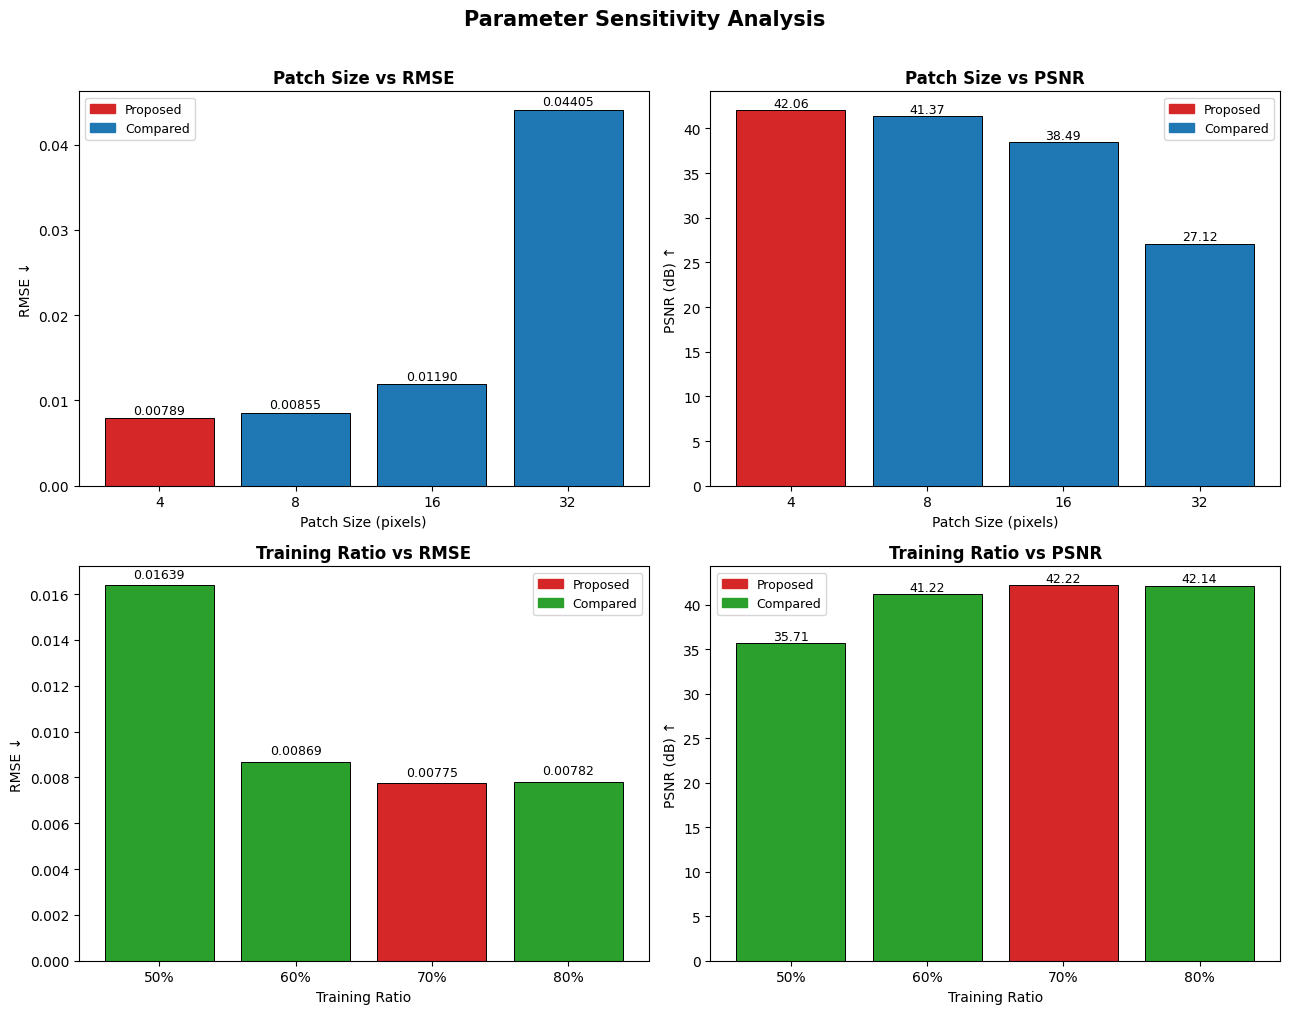


✅  Figure saved → /content/parameter_sensitivity_analysis.png
✅  CSVs saved → /content/patch_size_sensitivity.csv
✅             → /content/training_ratio_sensitivity.csv

PARAMETER SENSITIVITY SUMMARY

Experiment 1 — Patch Size (train_ratio = 70% fixed)
 patch_size    RMSE   PSNR
          4 0.00789 42.056
          8 0.00855 41.366
         16 0.01190 38.487
         32 0.04405 27.121

Experiment 2 — Training Ratio (patch_size = 4 fixed)
train_ratio    RMSE   PSNR
        50% 0.01639 35.708
        60% 0.00869 41.223
        70% 0.00775 42.218
        80% 0.00782 42.141

★  Proposed settings: patch_size=4, train_ratio=70%


In [ ]:
import tensorflow as tf
import numpy as np
import scipy.io
import os
import matplotlib.pyplot as plt
import pandas as pd
from math import log10
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# DATA PATH  – adjust to your Google Drive path
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH = "/content/drive/MyDrive/model"

# ─────────────────────────────────────────────────────────────────────────────
# FIXED HYPERPARAMETERS  (held constant during sensitivity sweeps)
# ─────────────────────────────────────────────────────────────────────────────
EPOCHS        = 50
BATCH_SIZE    = 32
LEARNING_RATE = 0.01

# Sweep ranges
PATCH_SIZES     = [4, 8, 16, 32]   # Comment 5 – patch size sensitivity
TRAINING_RATIOS = [0.5, 0.6, 0.7, 0.8]  # Comment 5 – training ratio sensitivity


# ─────────────────────────────────────────────────────────────────────────────
# HELPER: extract non-overlapping patches
# ─────────────────────────────────────────────────────────────────────────────
def extract_patches(data, patch_size):
    """Extract non-overlapping patches → (N, patch, patch, channels)."""
    patches = []
    for i in range(0, data.shape[0] - patch_size + 1, patch_size):
        for j in range(0, data.shape[1] - patch_size + 1, patch_size):
            patches.append(data[i:i + patch_size, j:j + patch_size, :])
    return np.array(patches)


# ─────────────────────────────────────────────────────────────────────────────
# HELPER: ECA layer
# ─────────────────────────────────────────────────────────────────────────────
class ECALayer(tf.keras.layers.Layer):
    def __init__(self, k_size=5, **kwargs):
        super().__init__(**kwargs)
        self.k_size = k_size
        self.global_avg_pool = tf.keras.layers.GlobalAveragePooling2D(keepdims=True)
        self.conv1d = tf.keras.layers.Conv1D(
            filters=1, kernel_size=k_size, padding="same",
            activation="sigmoid", use_bias=False
        )

    def call(self, inputs):
        gap       = self.global_avg_pool(inputs)
        gap_r     = tf.keras.layers.Reshape((-1, 1))(gap)
        attention = self.conv1d(gap_r)
        attention = tf.keras.layers.Reshape((1, 1, -1))(attention)
        return inputs * attention

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"k_size": self.k_size})
        return cfg


# ─────────────────────────────────────────────────────────────────────────────
# HELPER: build model (same architecture as original)
# ─────────────────────────────────────────────────────────────────────────────
def build_model(input_shape, output_channels):
    inputs = tf.keras.Input(shape=input_shape)

    # Initial feature extraction
    x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(inputs)

    # 3 Residual blocks with ECA
    for _ in range(3):
        shortcut = x
        x1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x2 = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
        x  = tf.keras.layers.Concatenate()([x1, x2])
        x  = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
        x  = ECALayer(k_size=5)(x)
        x  = tf.keras.layers.Add()([x, shortcut])

    # Reconstruction layer
    outputs = tf.keras.layers.Conv2D(output_channels, (1, 1), activation=None, padding='same')(x)
    outputs = ECALayer(k_size=5)(outputs)

    return tf.keras.Model(inputs, outputs)


# ─────────────────────────────────────────────────────────────────────────────
# HELPER: compute RMSE and PSNR
# ─────────────────────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred):
    mse  = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    psnr = 20 * log10(1.0 / rmse) if mse > 0 else float('inf')
    return round(rmse, 5), round(psnr, 3)


# ─────────────────────────────────────────────────────────────────────────────
# HELPER: single train + eval run
# ─────────────────────────────────────────────────────────────────────────────
def run_experiment(HR_MSI, HR_HSI, patch_size, train_ratio):
    Band_MSI = HR_MSI.shape[2]
    Band_HSI = HR_HSI.shape[2]

    # ── Split ────────────────────────────────────────────────────────────────
    split_idx    = int(HR_MSI.shape[1] * train_ratio)
    Train_MSI    = HR_MSI[:, :split_idx, :]
    Train_HSI    = HR_HSI[:, :split_idx, :]
    Test_MSI     = HR_MSI[:, split_idx:, :]
    Test_HSI     = HR_HSI[:, split_idx:, :]

    # ── Patches ──────────────────────────────────────────────────────────────
    Train_MSI_P = extract_patches(Train_MSI, patch_size)
    Train_HSI_P = extract_patches(Train_HSI, patch_size)
    Test_MSI_P  = extract_patches(Test_MSI,  patch_size)
    Test_HSI_P  = extract_patches(Test_HSI,  patch_size)

    if len(Train_MSI_P) == 0 or len(Test_MSI_P) == 0:
        print(f"  ⚠  Skipped – not enough data for patch={patch_size}, ratio={train_ratio}")
        return None, None

    # ── Model ────────────────────────────────────────────────────────────────
    tf.keras.backend.clear_session()
    model = build_model((patch_size, patch_size, Band_MSI), Band_HSI)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
        loss='mse'
    )

    # Train silently
    model.fit(
        Train_MSI_P, Train_HSI_P,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(Test_MSI_P, Test_HSI_P),
        verbose=0
    )

    # ── Evaluate ─────────────────────────────────────────────────────────────
    pred   = model.predict(Test_MSI_P, verbose=0)
    y_true = Test_HSI_P.reshape(-1, Band_HSI)
    y_pred = pred.reshape(-1, Band_HSI)

    return compute_metrics(y_true, y_pred)


# ─────────────────────────────────────────────────────────────────────────────
# LOAD & NORMALISE DATA  (done once)
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("Loading data …")
mat_data = scipy.io.loadmat(os.path.join(DATA_PATH, 'pavia_cnn.mat'))
HR_MSI   = mat_data['HR_MSI'].astype(np.float32) / np.max(mat_data['HR_MSI'])
HR_HSI   = mat_data['HR_HSI'].astype(np.float32) / np.max(mat_data['HR_HSI'])
print(f"HR-MSI shape : {HR_MSI.shape}")
print(f"HR-HSI shape : {HR_HSI.shape}")
print("=" * 60)


# ═════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 1 – PATCH SIZE SENSITIVITY
# (training ratio fixed at 0.70 – the proposed setting)
# ═════════════════════════════════════════════════════════════════════════════
print("\n▶  Experiment 1 : Patch Size Sensitivity  (train_ratio = 0.70 fixed)\n")

patch_results = {"patch_size": [], "RMSE": [], "PSNR": []}

for ps in PATCH_SIZES:
    print(f"  Testing patch_size = {ps}×{ps} …", end="  ")
    rmse, psnr = run_experiment(HR_MSI, HR_HSI, patch_size=ps, train_ratio=0.70)
    if rmse is not None:
        patch_results["patch_size"].append(ps)
        patch_results["RMSE"].append(rmse)
        patch_results["PSNR"].append(psnr)
        print(f"RMSE = {rmse:.5f}   PSNR = {psnr:.3f} dB")

df_patch = pd.DataFrame(patch_results)
print("\nPatch Size Sensitivity Results:")
print(df_patch.to_string(index=False))


# ═════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 2 – TRAINING RATIO SENSITIVITY
# (patch size fixed at 4 – the proposed setting)
# ═════════════════════════════════════════════════════════════════════════════
print("\n▶  Experiment 2 : Training Ratio Sensitivity  (patch_size = 4 fixed)\n")

ratio_results = {"train_ratio": [], "RMSE": [], "PSNR": []}

for tr in TRAINING_RATIOS:
    print(f"  Testing train_ratio = {int(tr*100)}% …", end="  ")
    rmse, psnr = run_experiment(HR_MSI, HR_HSI, patch_size=4, train_ratio=tr)
    if rmse is not None:
        ratio_results["train_ratio"].append(f"{int(tr*100)}%")
        ratio_results["RMSE"].append(rmse)
        ratio_results["PSNR"].append(psnr)
        print(f"RMSE = {rmse:.5f}   PSNR = {psnr:.3f} dB")

df_ratio = pd.DataFrame(ratio_results)
print("\nTraining Ratio Sensitivity Results:")
print(df_ratio.to_string(index=False))


# ═════════════════════════════════════════════════════════════════════════════
# PLOT RESULTS
# ═════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Parameter Sensitivity Analysis", fontsize=15, fontweight='bold', y=1.01)

proposed_patch = 4
proposed_ratio = "70%"

# ── Patch size – RMSE ────────────────────────────────────────────────────────
ax = axes[0, 0]
colors = ['#d62728' if str(p) == str(proposed_patch) else '#1f77b4'
          for p in df_patch["patch_size"]]
bars = ax.bar([str(p) for p in df_patch["patch_size"]], df_patch["RMSE"],
              color=colors, edgecolor='black', linewidth=0.7)
ax.set_title("Patch Size vs RMSE", fontweight='bold')
ax.set_xlabel("Patch Size (pixels)")
ax.set_ylabel("RMSE ↓")
for bar, val in zip(bars, df_patch["RMSE"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0002,
            f"{val:.5f}", ha='center', va='bottom', fontsize=9)
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#d62728', label='Proposed'),
    plt.Rectangle((0,0),1,1, color='#1f77b4', label='Compared')
], fontsize=9)

# ── Patch size – PSNR ────────────────────────────────────────────────────────
ax = axes[0, 1]
bars = ax.bar([str(p) for p in df_patch["patch_size"]], df_patch["PSNR"],
              color=colors, edgecolor='black', linewidth=0.7)
ax.set_title("Patch Size vs PSNR", fontweight='bold')
ax.set_xlabel("Patch Size (pixels)")
ax.set_ylabel("PSNR (dB) ↑")
for bar, val in zip(bars, df_patch["PSNR"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{val:.2f}", ha='center', va='bottom', fontsize=9)
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#d62728', label='Proposed'),
    plt.Rectangle((0,0),1,1, color='#1f77b4', label='Compared')
], fontsize=9)

# ── Training ratio – RMSE ────────────────────────────────────────────────────
ax = axes[1, 0]
colors_r = ['#d62728' if r == proposed_ratio else '#2ca02c'
            for r in df_ratio["train_ratio"]]
bars = ax.bar(df_ratio["train_ratio"], df_ratio["RMSE"],
              color=colors_r, edgecolor='black', linewidth=0.7)
ax.set_title("Training Ratio vs RMSE", fontweight='bold')
ax.set_xlabel("Training Ratio")
ax.set_ylabel("RMSE ↓")
for bar, val in zip(bars, df_ratio["RMSE"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0002,
            f"{val:.5f}", ha='center', va='bottom', fontsize=9)
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#d62728', label='Proposed'),
    plt.Rectangle((0,0),1,1, color='#2ca02c', label='Compared')
], fontsize=9)

# ── Training ratio – PSNR ────────────────────────────────────────────────────
ax = axes[1, 1]
bars = ax.bar(df_ratio["train_ratio"], df_ratio["PSNR"],
              color=colors_r, edgecolor='black', linewidth=0.7)
ax.set_title("Training Ratio vs PSNR", fontweight='bold')
ax.set_xlabel("Training Ratio")
ax.set_ylabel("PSNR (dB) ↑")
for bar, val in zip(bars, df_ratio["PSNR"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{val:.2f}", ha='center', va='bottom', fontsize=9)
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#d62728', label='Proposed'),
    plt.Rectangle((0,0),1,1, color='#2ca02c', label='Compared')
], fontsize=9)

plt.tight_layout()
plt.savefig("/content/parameter_sensitivity_analysis.png", dpi=180, bbox_inches='tight')
plt.show()
print("\n✅  Figure saved → /content/parameter_sensitivity_analysis.png")


# ═════════════════════════════════════════════════════════════════════════════
# SAVE RESULTS TO CSV
# ═════════════════════════════════════════════════════════════════════════════
df_patch.to_csv("/content/patch_size_sensitivity.csv", index=False)
df_ratio.to_csv("/content/training_ratio_sensitivity.csv", index=False)
print("✅  CSVs saved → /content/patch_size_sensitivity.csv")
print("✅             → /content/training_ratio_sensitivity.csv")

# ─────────────────────────────────────────────────────────────────────────────
# PRINT FINAL SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("PARAMETER SENSITIVITY SUMMARY")
print("=" * 60)
print("\nExperiment 1 — Patch Size (train_ratio = 70% fixed)")
print(df_patch.to_string(index=False))
print("\nExperiment 2 — Training Ratio (patch_size = 4 fixed)")
print(df_ratio.to_string(index=False))
print("\n★  Proposed settings: patch_size=4, train_ratio=70%")
print("=" * 60)

In [8]:
import tensorflow as tf
import numpy as np
import scipy.io
import os
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error
from math import log10

# ==============================================================================
# 1. PARAMETER SETTINGS & DATA LOADING (From your original code)
# ==============================================================================
patch_size = 16          # Input patch size
epoch = 50               # Number of training epochs
batch_size = 32          # Standard batch size
learning_rate_base = 0.01# Initial learning rate

print('Loading Data and Generating Training/Testing Samples...')
DATA_PATH = "/content/drive/MyDrive/model"

# Load Pavia University Hyperspectral Dataset (Update path if needed)
mat_data = scipy.io.loadmat(os.path.join(DATA_PATH, 'new-dataset(ali-hyperion).mat'))
HR_MSI = mat_data['msi_data']
HR_HSI = mat_data['hyper_data']

print(f"HR_MSI Shape: {HR_MSI.shape}")
print(f"HR_HSI Shape: {HR_HSI.shape}")

# Get image dimensions
Height_HR, Width_HR, Band_MSI = HR_MSI.shape
Band_HSI = HR_HSI.shape[2]

# Normalize Data
HR_MSI = HR_MSI.astype(np.float32) / np.max(HR_MSI)
HR_HSI = HR_HSI.astype(np.float32) / np.max(HR_HSI)

# Split Data into Training & Testing (70/30)
split_index = int(Width_HR * 0.7)
Training_MSI = HR_MSI[:, :split_index, :]
Training_HSI = HR_HSI[:, :split_index, :]
Testing_MSI = HR_MSI[:, split_index:, :]
Testing_HSI = HR_HSI[:, split_index:, :]

def extract_patches(data, patch_size):
    """ Extracts patches from hyperspectral images """
    patches = []
    for i in range(0, data.shape[0] - patch_size + 1, patch_size):
        for j in range(0, data.shape[1] - patch_size + 1, patch_size):
            patch = data[i:i + patch_size, j:j + patch_size, :]
            patches.append(patch)
    return np.array(patches)

Train_MSI_Patches = extract_patches(Training_MSI, patch_size)
Train_HSI_Patches = extract_patches(Training_HSI, patch_size)
Test_MSI_Patches = extract_patches(Testing_MSI, patch_size)
Test_HSI_Patches = extract_patches(Testing_HSI, patch_size)

print(f"Train MSI Shape: {Train_MSI_Patches.shape}, Train HSI Shape: {Train_HSI_Patches.shape}")
print(f"Test MSI Shape: {Test_MSI_Patches.shape}, Test HSI Shape: {Test_HSI_Patches.shape}")


# ==============================================================================
# 2. MODEL CUSTOM LAYERS (ECA & Self-Attention)
# ==============================================================================
class ECALayer(tf.keras.layers.Layer):
    """ Efficient Channel Attention (ECA) as a Keras Layer """
    def __init__(self, k_size=5, **kwargs):
        super(ECALayer, self).__init__(**kwargs)
        self.k_size = k_size
        self.global_avg_pool = tf.keras.layers.GlobalAveragePooling2D(keepdims=True)
        self.conv1d = tf.keras.layers.Conv1D(filters=1, kernel_size=k_size, padding="same", activation="sigmoid", use_bias=False)

    def call(self, inputs):
        gap = self.global_avg_pool(inputs)
        gap_reshaped = tf.keras.layers.Reshape((-1, 1))(gap)
        attention = self.conv1d(gap_reshaped)
        attention = tf.keras.layers.Reshape((1, 1, -1))(attention)
        return inputs * attention

class SpatialSelfAttention(tf.keras.layers.Layer):
    """ Multi-Head Self Attention adapted for spatial (Image) features """
    def __init__(self, num_heads=4, key_dim=64, **kwargs):
        super(SpatialSelfAttention, self).__init__(**kwargs)
        self.mha = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        H = tf.shape(inputs)[1]
        W = tf.shape(inputs)[2]
        C = tf.shape(inputs)[3]

        # Flatten spatial dimensions to create a sequence
        x_flat = tf.reshape(inputs, (batch_size, H * W, C))

        # Apply Self-Attention
        attn_out = self.mha(x_flat, x_flat)

        # Reshape back to spatial dimensions
        output = tf.reshape(attn_out, (batch_size, H, W, C))
        return output


# ==============================================================================
# 3. MODULAR MODEL BUILDER
# ==============================================================================
def build_model(input_shape, output_channels, experiment_type='baseline'):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(inputs)

    # Inject noise if simulating diffusion denoising
    if experiment_type == 'diffusion':
        x = tf.keras.layers.GaussianNoise(0.05)(x)

    shortcut = x

    # 3 Residual Blocks
    for _ in range(3):
        x1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x2 = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)
        x = tf.keras.layers.Concatenate()([x1, x2])
        x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu', padding='same')(x)

        if experiment_type == 'attention':
            x = SpatialSelfAttention(num_heads=4, key_dim=64)(x)
        else:
            x = ECALayer(k_size=5)(x)

        x = tf.keras.layers.Add()([x, shortcut])

        if experiment_type == 'diffusion':
            x = tf.keras.layers.GaussianNoise(0.05)(x)

        shortcut = x

    # Output Layer
    outputs = tf.keras.layers.Conv2D(output_channels, (1, 1), activation=None, padding='same')(x)

    if experiment_type in ['baseline', 'diffusion']:
        outputs = ECALayer(k_size=5)(outputs)

    model = tf.keras.Model(inputs, outputs)
    return model


# ==============================================================================
# 4. EXECUTION & ABLATION STUDY
# ==============================================================================
input_shape = (patch_size, patch_size, Band_MSI)
output_channels = Band_HSI

# Run 1: Baseline (ECA)
print("\n--- Training Baseline (ECA) ---")
model_base = build_model(input_shape, output_channels, experiment_type='baseline')
model_base.compile(optimizer=tf.keras.optimizers.Adam(learning_rate_base), loss='mse')
model_base.fit(Train_MSI_Patches, Train_HSI_Patches, batch_size=batch_size, epochs=epoch, validation_data=(Test_MSI_Patches, Test_HSI_Patches))

# Run 2: Transformer Core (Self-Attention)
print("\n--- Training Transformer Core (Self-Attention) ---")
model_attn = build_model(input_shape, output_channels, experiment_type='attention')
model_attn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate_base), loss='mse')
model_attn.fit(Train_MSI_Patches, Train_HSI_Patches, batch_size=batch_size, epochs=epoch, validation_data=(Test_MSI_Patches, Test_HSI_Patches))

# Run 3: Diffusion Core (Gaussian Noise)
print("\n--- Training Diffusion Core (Gaussian Noise) ---")
model_diff = build_model(input_shape, output_channels, experiment_type='diffusion')
model_diff.compile(optimizer=tf.keras.optimizers.Adam(learning_rate_base), loss='mse')
model_diff.fit(Train_MSI_Patches, Train_HSI_Patches, batch_size=batch_size, epochs=epoch, validation_data=(Test_MSI_Patches, Test_HSI_Patches))


# ==============================================================================
# 5. EVALUATION (UPDATED WITH SAM & SSIM)
# ==============================================================================
def evaluate_model(model, test_msi, test_hsi, model_name="Model"):
    # Generate predictions
    predicted_HSI = model.predict(test_msi, verbose=0)

    # Flatten spatial dimensions for RMSE, PSNR, and SAM
    # Shape becomes: (total_pixels, Band_HSI)
    y_true_flat = test_hsi.reshape(-1, Band_HSI)
    y_pred_flat = predicted_HSI.reshape(-1, Band_HSI)

    # 1. RMSE (Root Mean Squared Error)
    rmse = np.sqrt(np.mean((y_true_flat - y_pred_flat) ** 2))

    # 2. PSNR (Peak Signal-to-Noise Ratio)
    mse = np.mean((y_true_flat - y_pred_flat) ** 2)
    psnr = float('inf') if mse == 0 else 20 * log10(1.0 / np.sqrt(mse))

    # 3. SAM (Spectral Angle Mapper)
    # Calculate dot product and norms for each pixel vector
    dot_product = np.sum(y_true_flat * y_pred_flat, axis=1)
    norm_true = np.linalg.norm(y_true_flat, axis=1)
    norm_pred = np.linalg.norm(y_pred_flat, axis=1)

    # Calculate cosine similarity, add epsilon to denominator to avoid division by zero
    cos_sim = dot_product / (norm_true * norm_pred + 1e-10)
    # Clip values to valid range [-1, 1] to prevent NaN errors in arccos
    cos_sim = np.clip(cos_sim, -1.0, 1.0)

    # Calculate angle in radians, convert to degrees, and average across all pixels
    sam_rad = np.arccos(cos_sim)
    sam_deg = np.mean(sam_rad) * (180.0 / np.pi)

    # 4. SSIM (Structural Similarity Index Measure)
    # tf.image.ssim calculates SSIM per image patch in the batch.
    # max_val is 1.0 because the data was normalized earlier (divided by np.max)
# Inside the evaluate_model function, change the SSIM line to:
    ssim_val = tf.reduce_mean(tf.image.ssim(test_hsi, predicted_HSI, max_val=1.0, filter_size=7)).numpy()
    # Print Results
    print(f"\n{model_name} Results:")
    print(f"🔹 Params: {model.count_params():,}")
    print(f"🔹 RMSE:   {rmse:.4f}")
    print(f"🔹 PSNR:   {psnr:.2f} dB")
    print(f"🔹 SAM:    {sam_deg:.2f}°")
    print(f"🔹 SSIM:   {ssim_val:.4f}")

# Run evaluations
evaluate_model(model_base, Test_MSI_Patches, Test_HSI_Patches, "Baseline (ECA)")
evaluate_model(model_attn, Test_MSI_Patches, Test_HSI_Patches, "Transformer Core (Self-Attention)")
evaluate_model(model_diff, Test_MSI_Patches, Test_HSI_Patches, "Diffusion Core (Noise)")

Loading Data and Generating Training/Testing Samples...
HR_MSI Shape: (196, 196, 8)
HR_HSI Shape: (196, 196, 178)
Train MSI Shape: (96, 16, 16, 8), Train HSI Shape: (96, 16, 16, 178)
Test MSI Shape: (36, 16, 16, 8), Test HSI Shape: (36, 16, 16, 178)

--- Training Baseline (ECA) ---
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - loss: 0.0531 - val_loss: 0.0190
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0189 - val_loss: 0.0101
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0100 - val_loss: 0.0062
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0059 - val_loss: 0.0040
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0035 - val_loss: 0.0026
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0015 - val_loss: 0.0019
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0013 - val_loss: 0.0019
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - los